# Thiranex Data Science Internship — Task 4
## Project Title: Health Risk Analysis & Heart Disease Prediction
**Author:** Data Science Intern  
**Domain:** Healthcare & Clinical Data Science  
**Dataset:** UCI Heart Disease Dataset  
**Due Date:** 23 October 2026  
***

### 1. Executive Summary & Research Problem
Cardiovascular diseases (CVDs) are the leading cause of global mortality, taking an estimated 17.9 million lives each year according to the World Health Organization (WHO). Early risk identification and quantitative risk stratification enable early intervention and lifestyle modifications.

**Core Objectives:**
1. **Clinical Data Audit & Quality Control**: Inspect 303 patient records across 14 clinical features (age, blood pressure, cholesterol, max heart rate, ST depression, chest pain classification).
2. **Exploratory Clinical Analytics (EDA)**: Identify key physiological indicators that correlate with heart disease prevalence.
3. **Leak-Free Supervised Modeling**: Train an interpretable Baseline (Logistic Regression), a Decision Tree Classifier, and an ensemble Random Forest Classifier using `CustomColumnTransformer` to ensure zero data leakage.
4. **Model Evaluation & Clinical Risk Scoring**: Evaluate holdout test performance across Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics.


---
### 2. Business & Clinical Problem Statement
The objective is to train a supervised machine learning model that predicts heart disease diagnosis (`target` = 1 for disease present, `target` = 0 for normal) using patient physiological attributes.

***
> ### ⚠️ MANDATORY EDUCATIONAL & NON-CLINICAL DISCLAIMER
> **THIS PROJECT IS STRICTLY AN EDUCATIONAL INTERNSHIP DEMONSTRATION.**  
> The machine learning models, statistical calculations, and predictions generated in this notebook are **FOR EDUCATIONAL AND APPLIED DATA SCIENCE LEARNING ONLY**.  
> **THE PREDICTIONS DO NOT CONSTITUTE MEDICAL DIAGNOSES AND MUST NEVER REPLACE CLINICAL ASSESSMENT, MEDICAL ADVICE, OR DIAGNOSTIC EVALUATION BY A QUALIFIED PHYSICIAN.**
***


---
### 3. Dataset Overview
We utilize the **UCI Heart Disease Dataset** (Cleveland Clinic database).
* **Sample Size:** 303 patient records
* **Clinical Attributes:** 13 input features + 1 binary target (`target`)
* **Target Classes:** 165 Disease Present (54.5%), 138 Normal / Healthy (45.5%)


---
### 4. Environment Setup & Library Imports
We import core scientific computing libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`), along with modular functions from `src/`.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Add project root to sys.path
sys.path.append(os.path.abspath(".."))

from src.preprocessing import (
    load_raw_data,
    inspect_data,
    clean_raw_dataframe,
    get_preprocessor,
    split_data
)
from src.analysis import (
    compute_clinical_summary_stats,
    plot_target_distribution,
    plot_age_distribution_by_target,
    plot_chest_pain_vs_target,
    plot_cholesterol_bp_scatter,
    plot_max_heart_rate_boxplot,
    plot_correlation_heatmap,
    plot_exercise_angina_st_depression,
    plot_pairwise_feature_importance
)
from src.train import build_model_pipelines, train_all_models
from src.evaluate import (
    evaluate_all_models,
    plot_confusion_matrices,
    plot_roc_curves,
    plot_model_comparison,
    plot_feature_importance
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline

print("Task 4 Health Data Project libraries successfully imported!")


Task 4 Health Data Project libraries successfully imported!


---
### 5. Data Loading & Initial Inspection
We ingest the raw, untouched dataset from `data/raw/heart.csv`.


In [2]:
raw_data_path = os.path.join("..", "data", "raw", "heart.csv")
df_raw = load_raw_data(raw_data_path)

print(f"Dataset Shape: {df_raw.shape[0]} patients x {df_raw.shape[1]} clinical attributes")
display(df_raw.head())


[INFO] Loading raw Heart Disease dataset from: ..\data\raw\heart.csv
[INFO] Raw dataset loaded successfully. Shape: (303, 14)
Dataset Shape: 303 patients x 14 clinical attributes


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3000,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5000,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4000,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8000,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6000,2,0,2,1


---
### 6. Data Understanding & Structural Quality Audit
We audit data types, missing values, duplicates, and target class balance.


In [3]:
inspection = inspect_data(df_raw)

print("Column Data Types:")
for col, dt in inspection['dtypes'].items():
    print(f" - {col:15s}: {dt}")

print("\nMissing Values Audit:", inspection['missing_values'])
print("Duplicate Rows Count:", inspection['duplicate_rows'])
print("Target Class Counts:", inspection['target_distribution'])


Column Data Types:
 - age            : int64
 - sex            : int64
 - cp             : int64
 - trestbps       : int64
 - chol           : int64
 - fbs            : int64
 - restecg        : int64
 - thalach        : int64
 - exang          : int64
 - oldpeak        : float64
 - slope          : int64
 - ca             : int64
 - thal           : int64
 - target         : int64

Missing Values Audit: {'age': 0, 'sex': 0, 'cp': 0, 'trestbps': 0, 'chol': 0, 'fbs': 0, 'restecg': 0, 'thalach': 0, 'exang': 0, 'oldpeak': 0, 'slope': 0, 'ca': 0, 'thal': 0, 'target': 0}
Duplicate Rows Count: 1
Target Class Counts: {1: 165, 0: 138}


[SAVED] Target distribution plot saved to: ..\visualizations\00_target_distribution.png


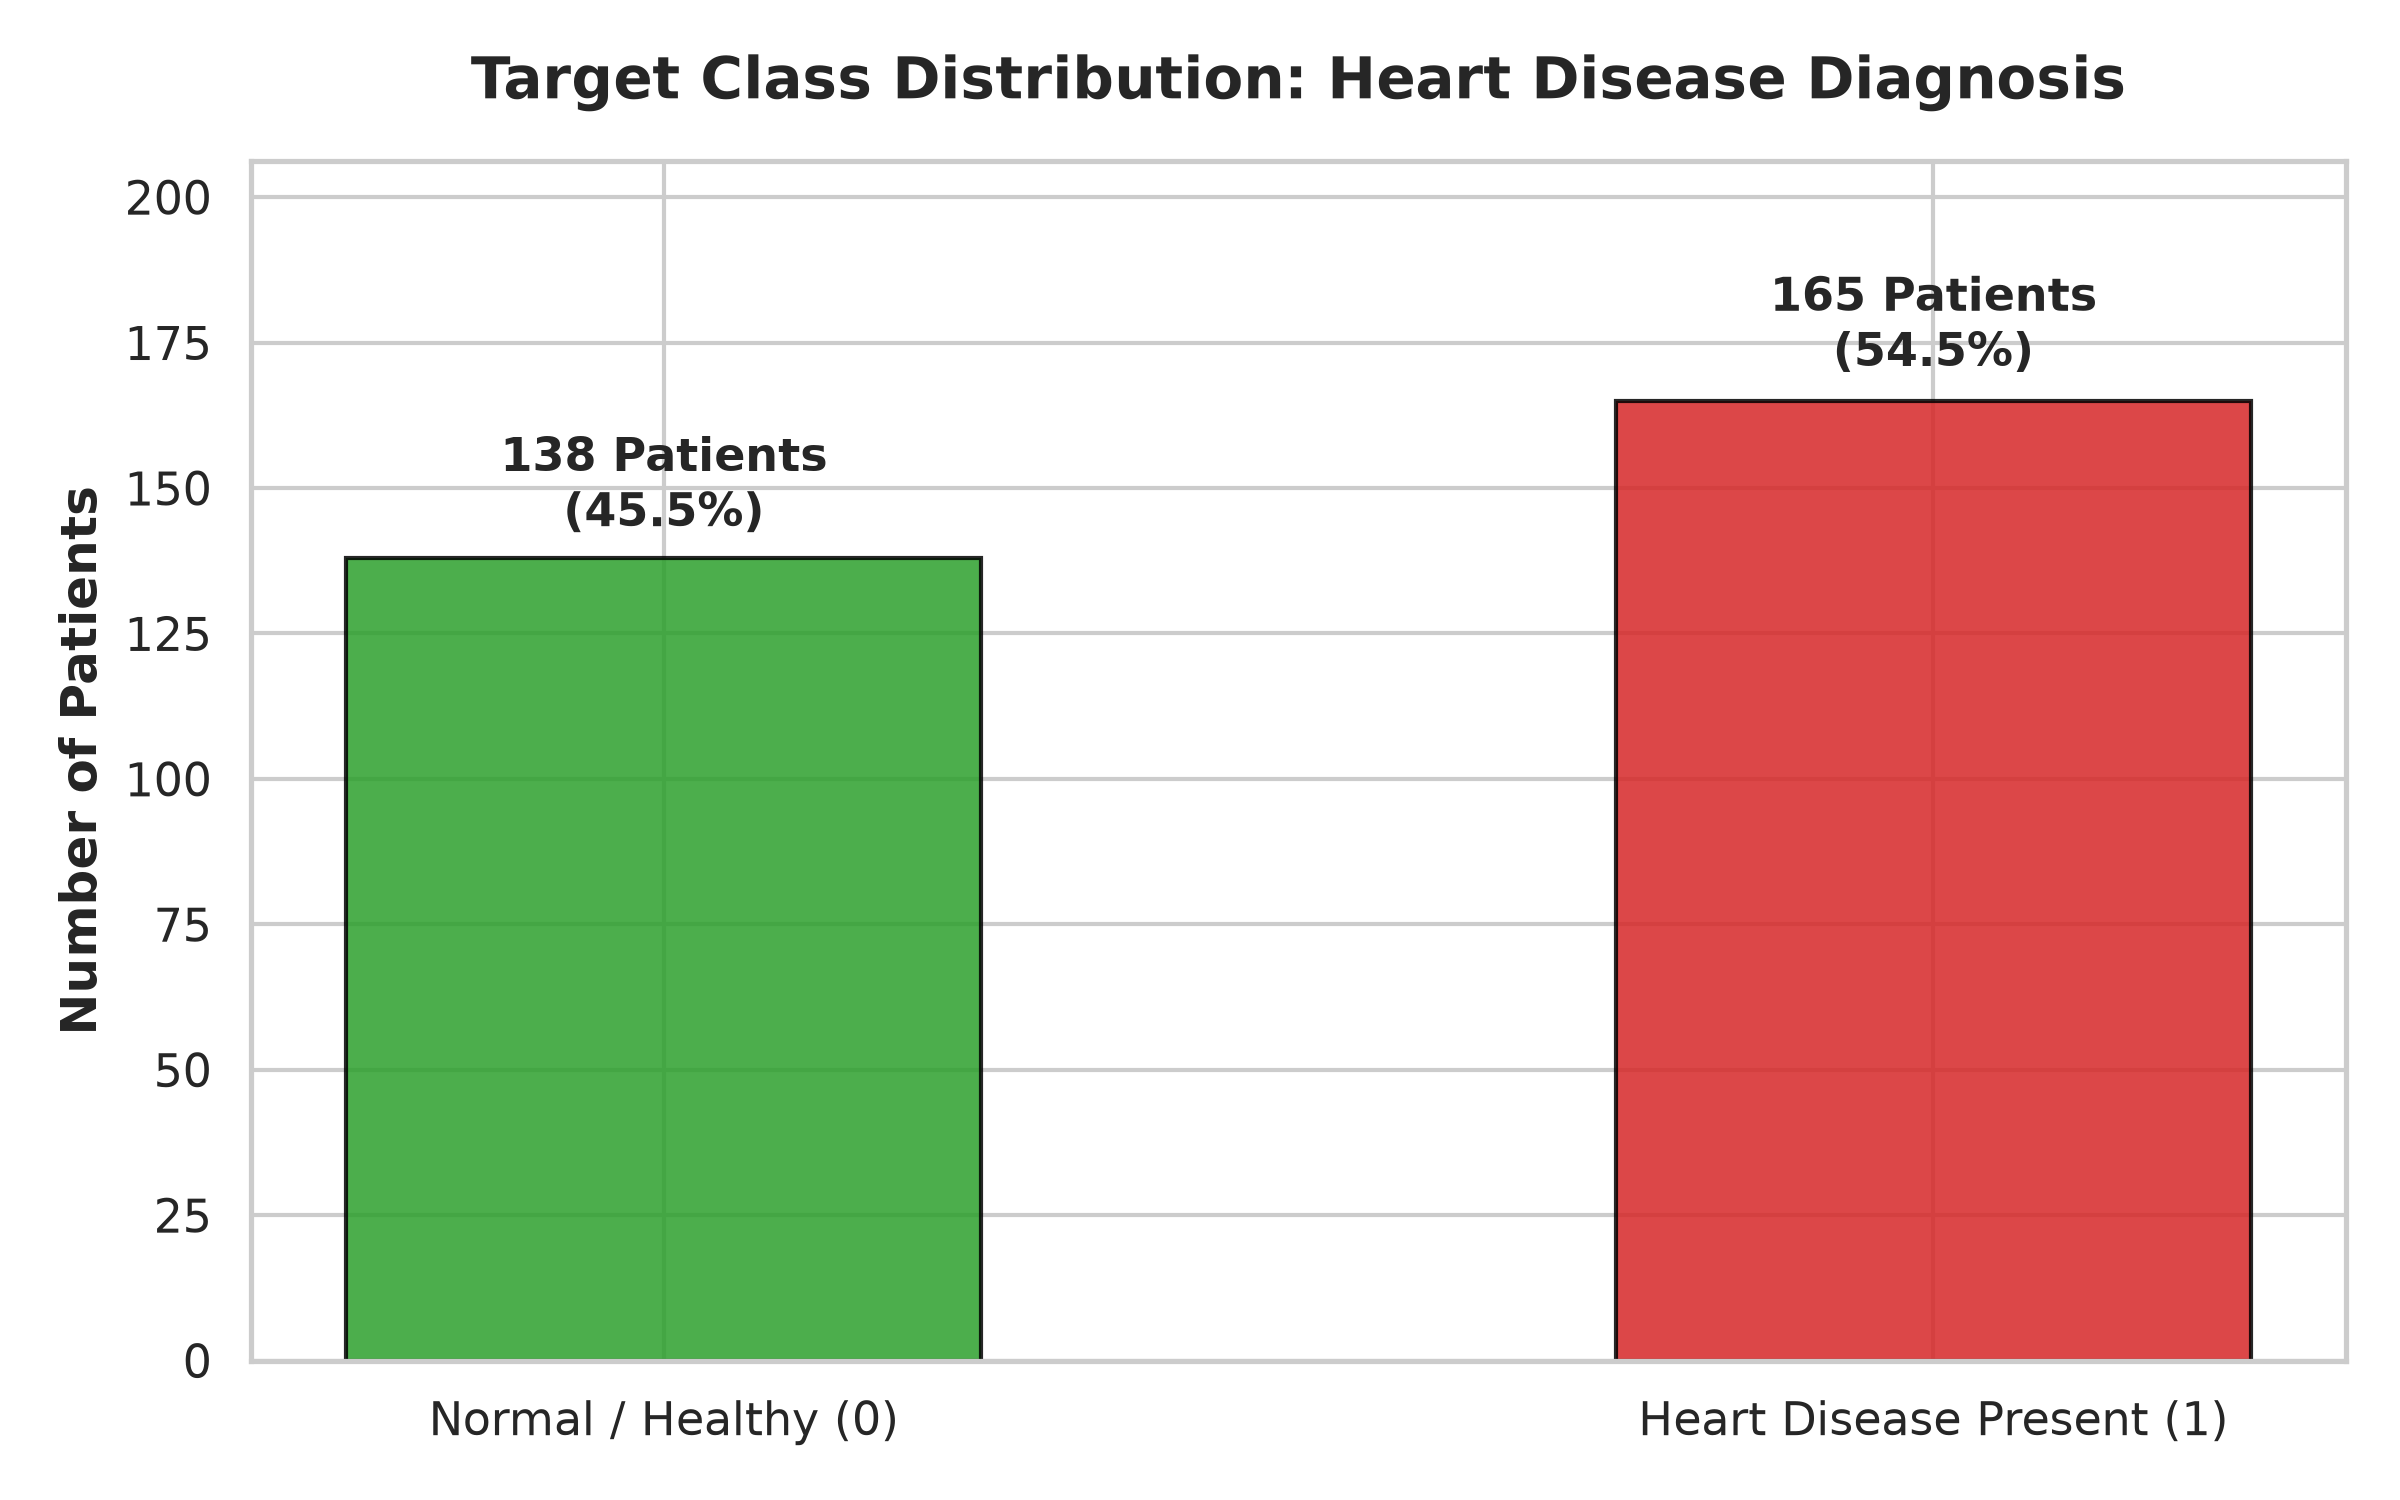

In [4]:
# Target Distribution Visual
viz_dir = os.path.join("..", "visualizations")
plot_target_distribution(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "00_target_distribution.png"))


---
### 7. Data Preprocessing & Column Transformer
1. Exact duplicates removed.
2. Clinical features isolated:
   - Numerical: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
   - Categorical: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`
3. `CustomColumnTransformer` applies Z-score scaling to numerical features and One-Hot Encoding to categorical features **strictly on `X_train`**.


In [5]:
X, y, tracking = clean_raw_dataframe(df_raw)
preprocessor = get_preprocessor(X)

print("Clean Feature Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)


[INFO] Numerical Clinical Features (5): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
[INFO] Categorical Clinical Features (8): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Clean Feature Matrix X Shape: (302, 13)
Target Vector y Shape: (302,)


---
### 8. Exploratory Clinical Data Analysis (EDA)

We compute clinical summary statistics and plot diagnostic EDA dashboards.


In [6]:
df_summary = compute_clinical_summary_stats(df_raw)
print("=== CLINICAL SUMMARY STATISTICS ===")
display(df_summary)


=== CLINICAL SUMMARY STATISTICS ===


,Feature,Mean,StdDev,Median,Min,Q25 (25%),Q75 (75%),Max,IQR
0,age,54.3700,9.0800,55.0000,29.0000,47.5000,61.0000,77.0000,13.5000
1,trestbps,131.6200,17.5400,130.0000,94.0000,120.0000,140.0000,200.0000,20.0000
2,chol,246.2600,51.8300,240.0000,126.0000,211.0000,274.5000,564.0000,63.5000
3,thalach,149.6500,22.9100,153.0000,71.0000,133.5000,166.0000,202.0000,32.5000
4,oldpeak,1.0400,1.1600,0.8000,0.0000,0.0000,1.6000,6.2000,1.6000


[SAVED] Age distribution plot saved to: ..\visualizations\01_age_distribution_by_target.png


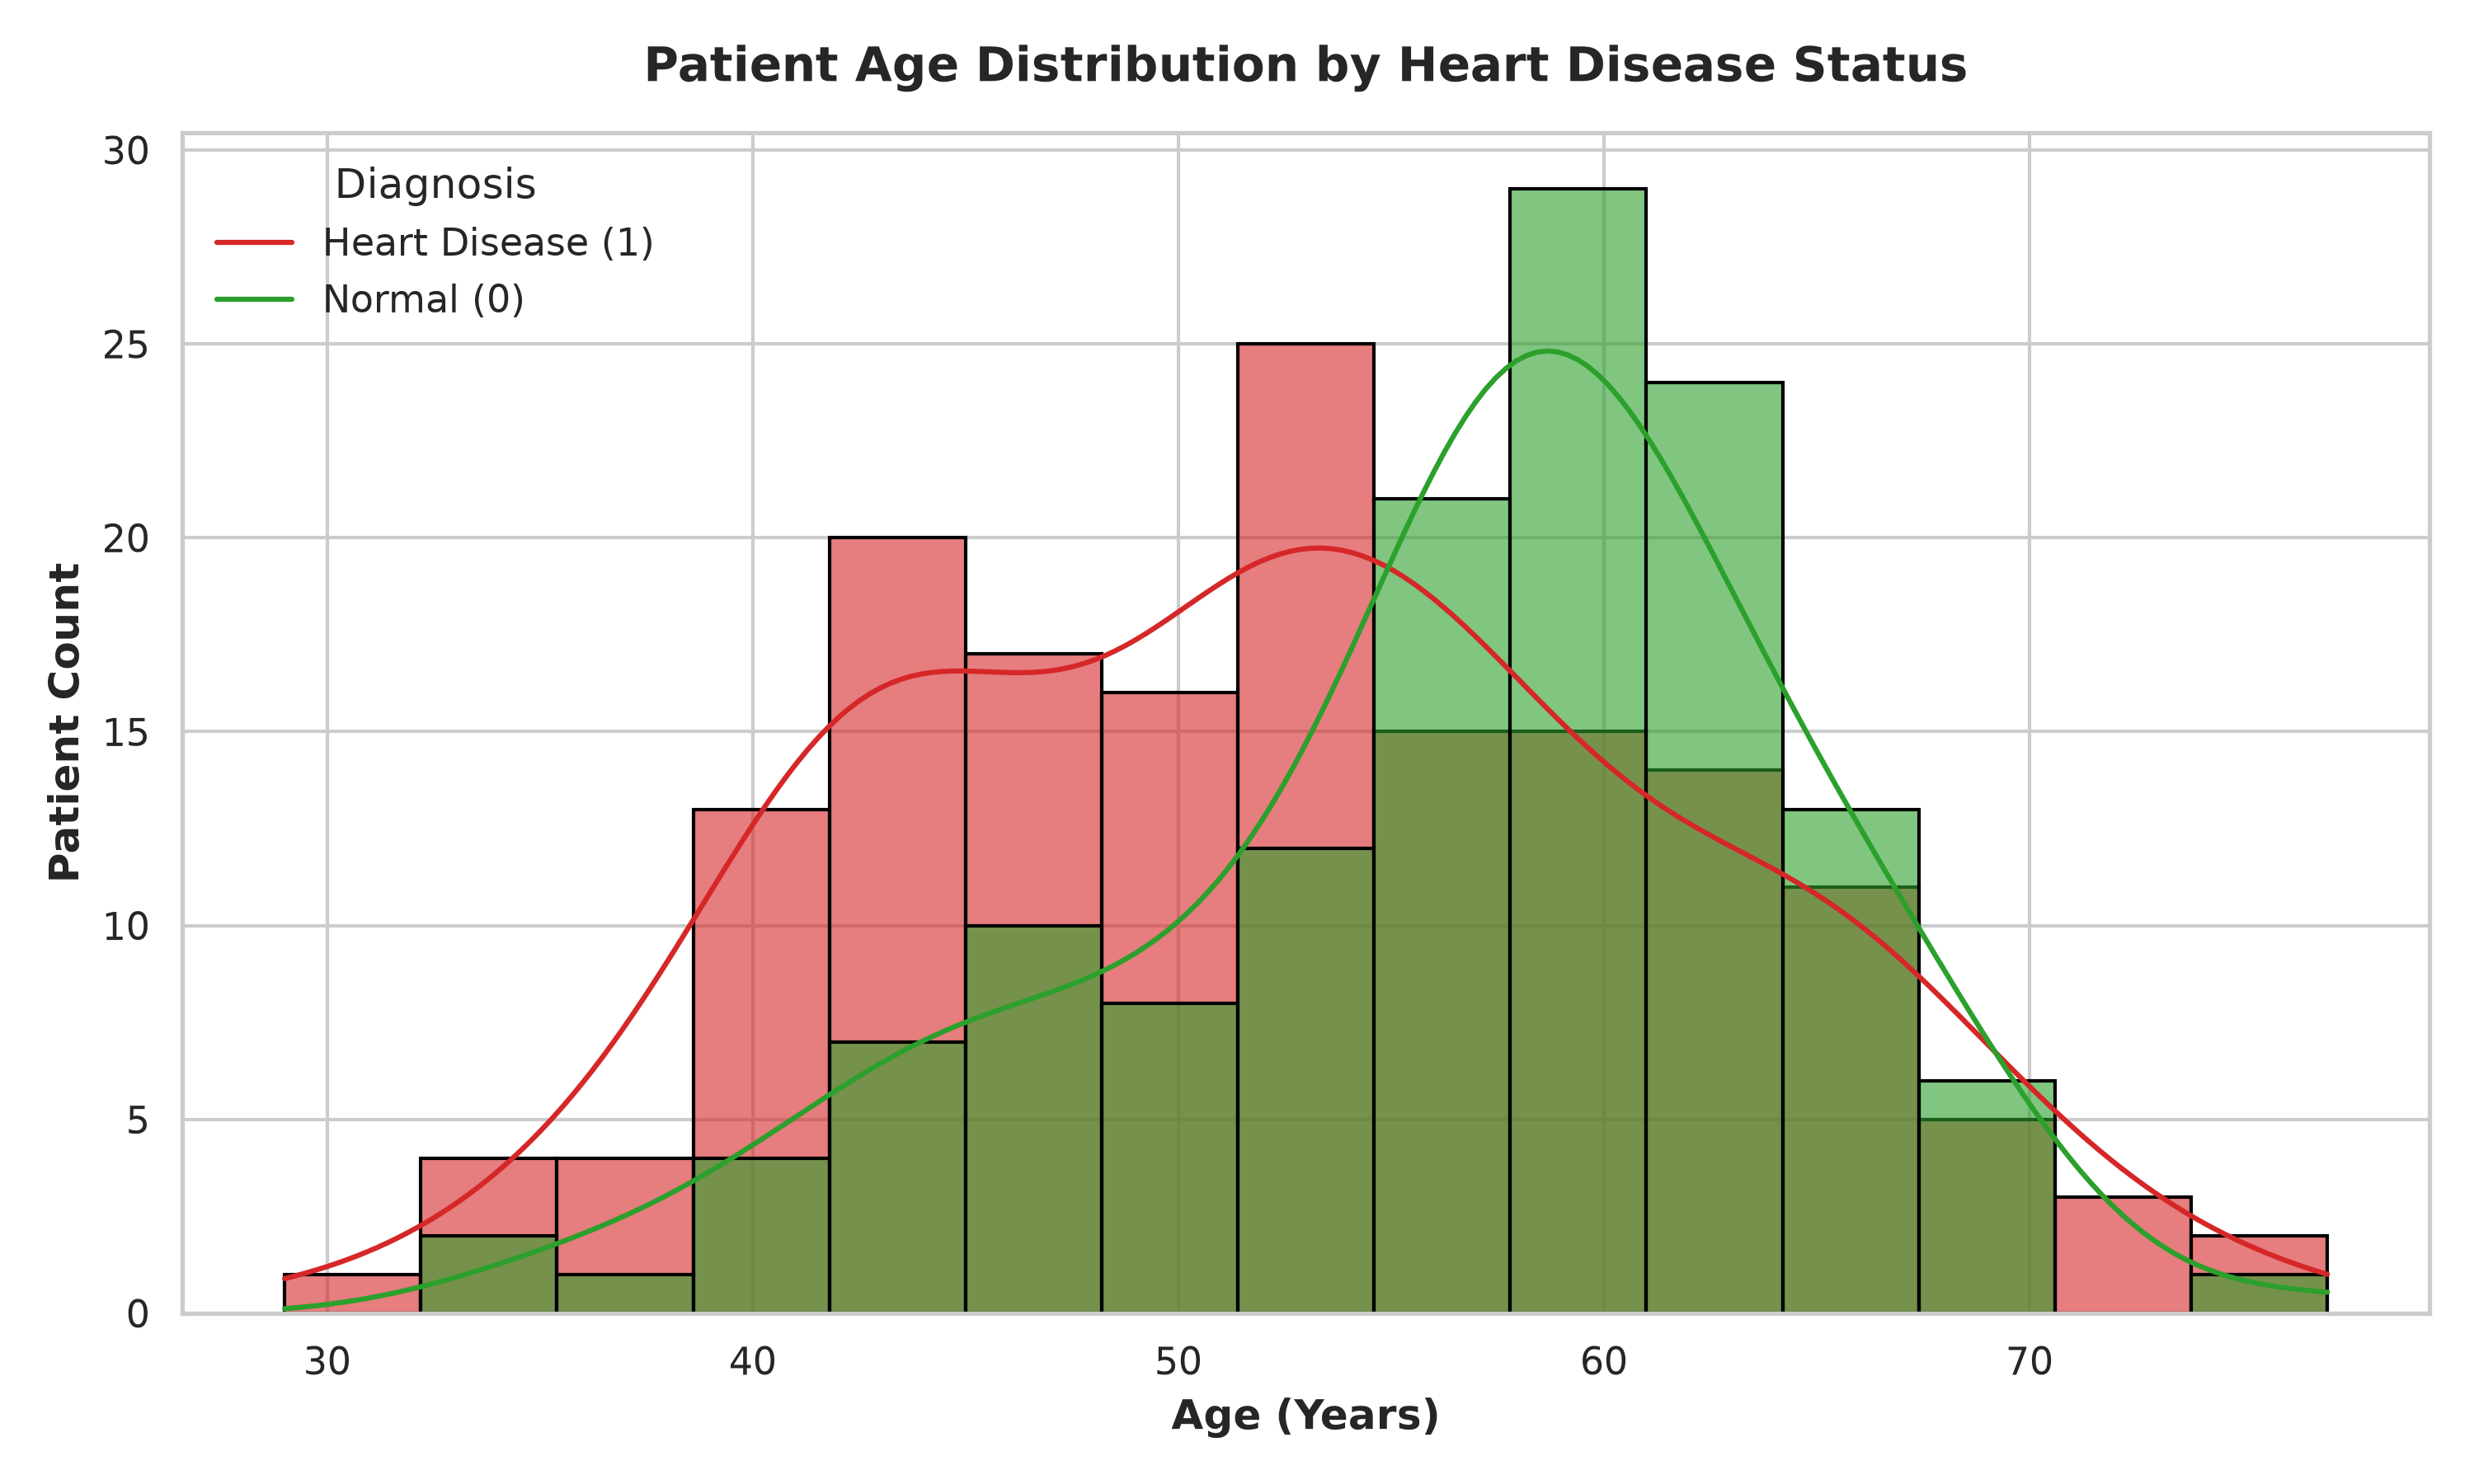

In [7]:
# Age Distribution by Diagnosis
plot_age_distribution_by_target(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "01_age_distribution_by_target.png"))


[SAVED] Chest pain vs target plot saved to: ..\visualizations\02_chest_pain_vs_target.png


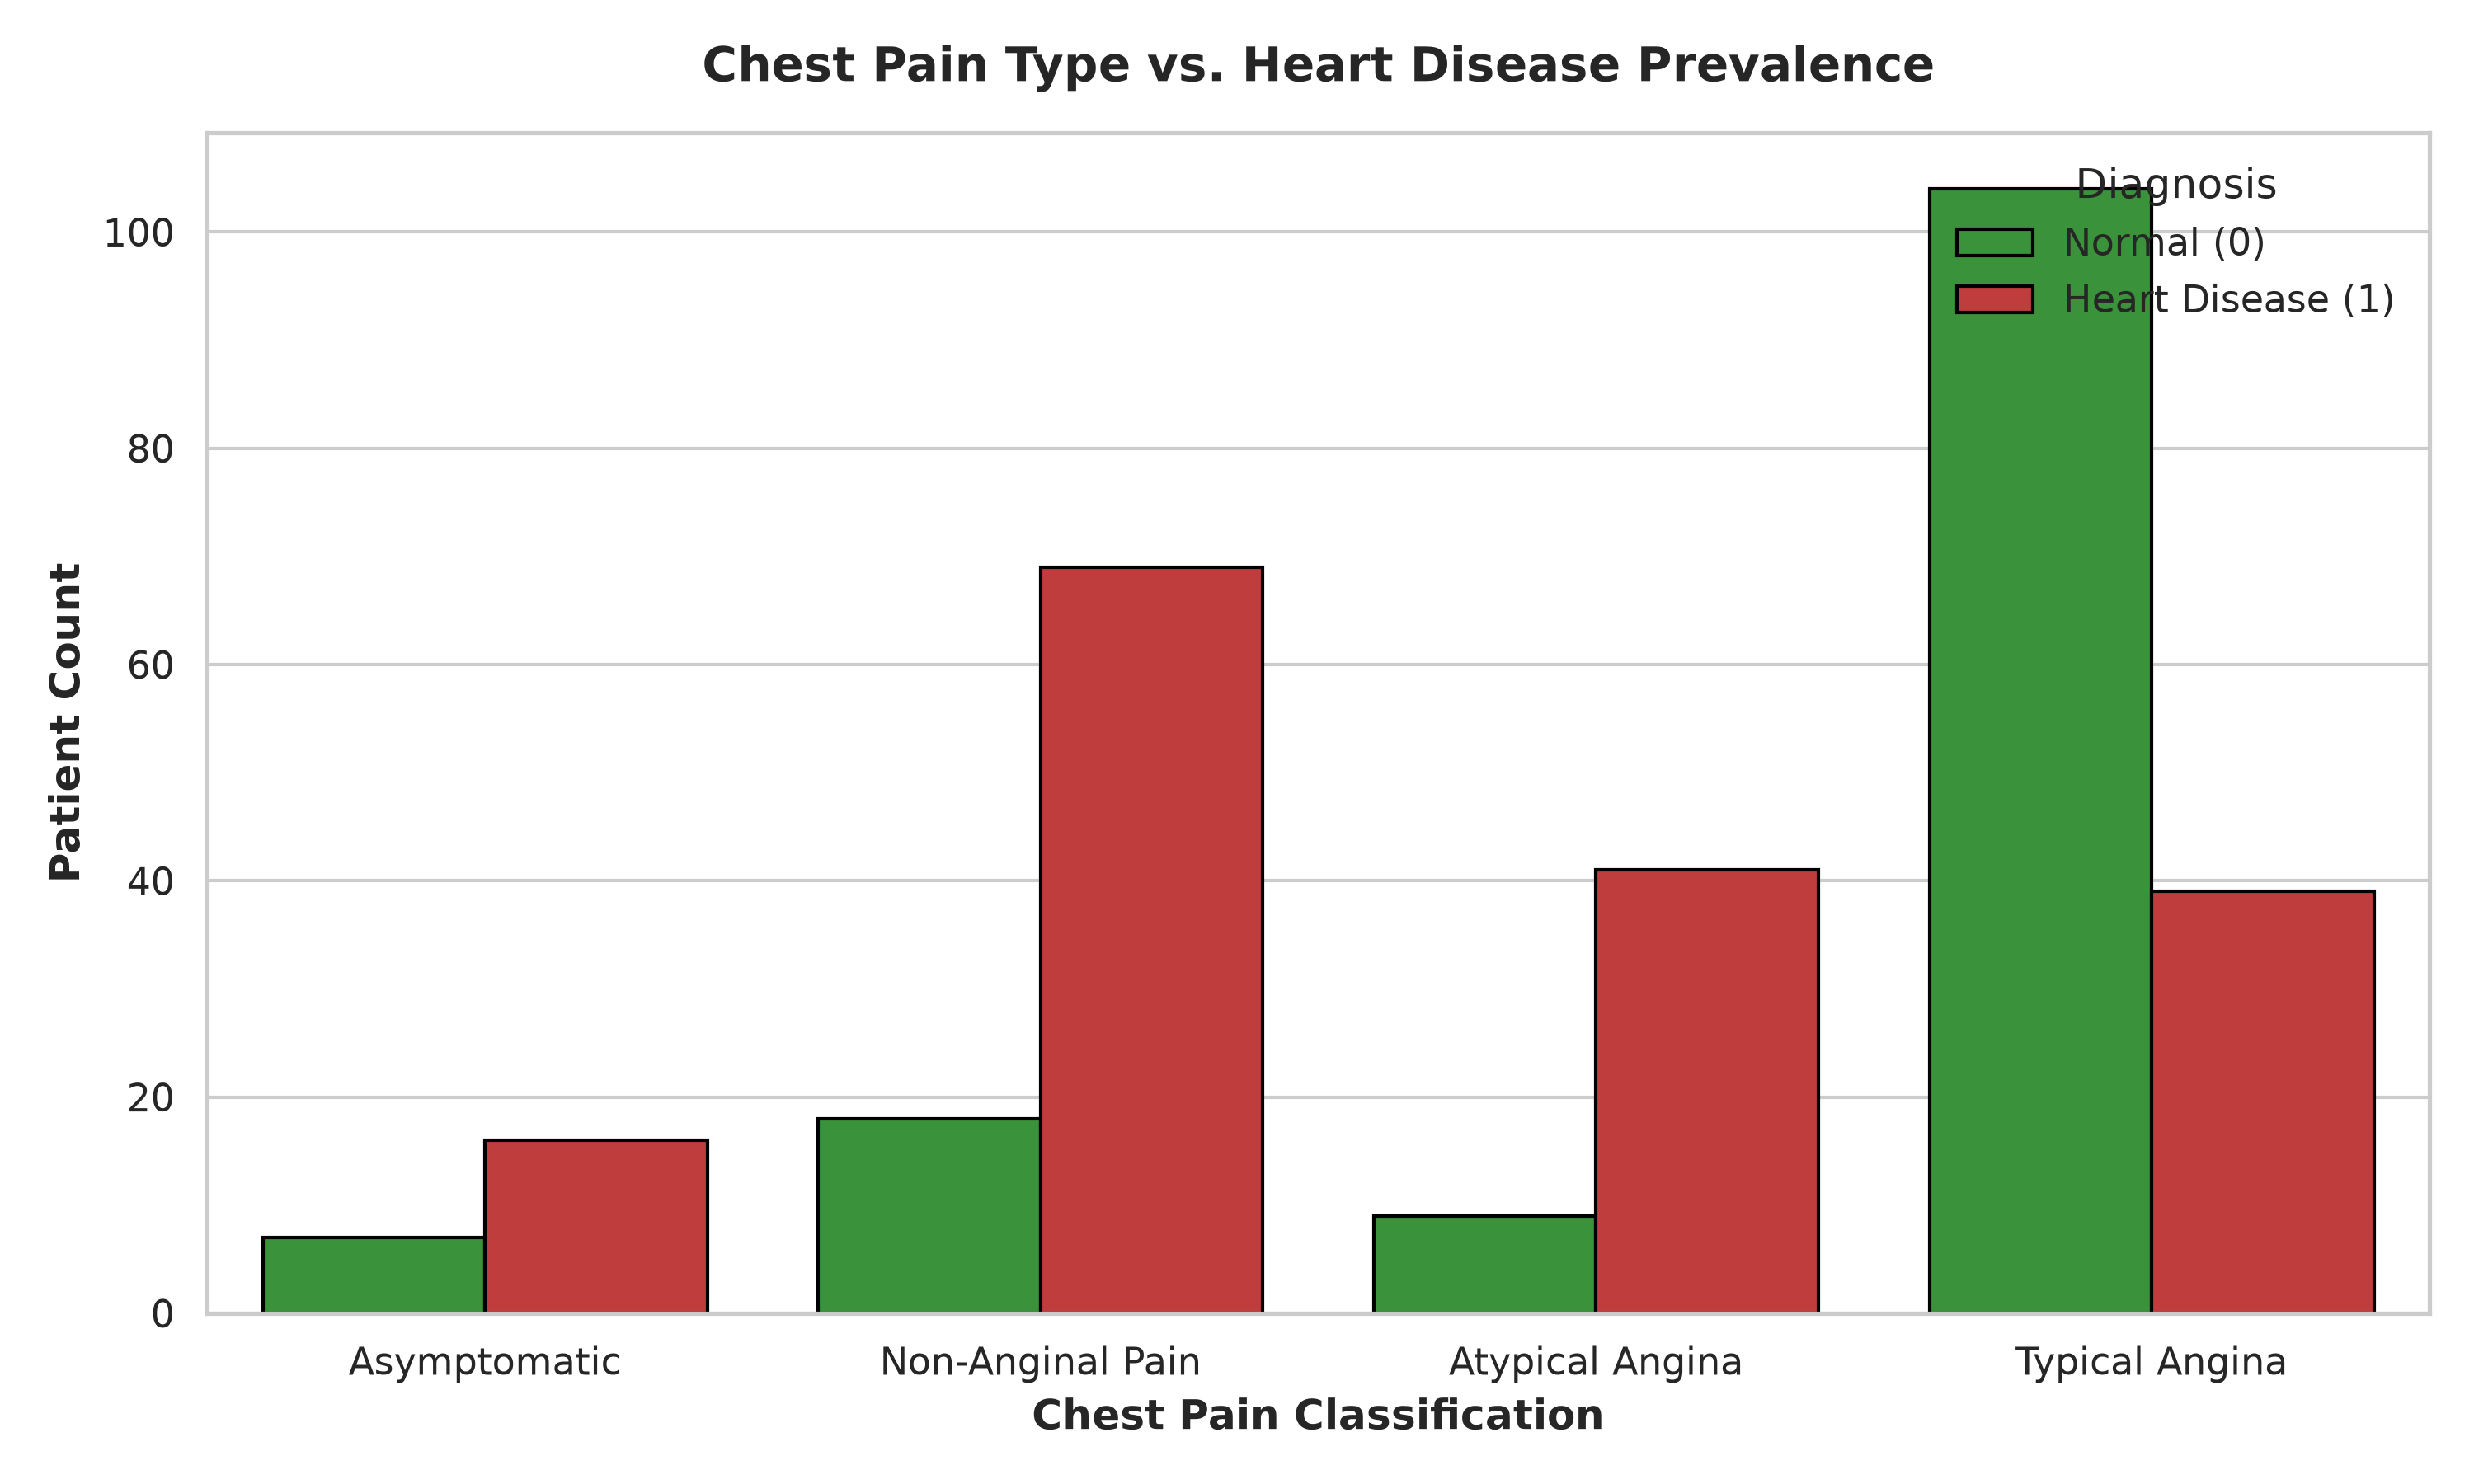

In [8]:
# Chest Pain Classification vs Target
plot_chest_pain_vs_target(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "02_chest_pain_vs_target.png"))


[SAVED] Cholesterol vs BP scatter plot saved to: ..\visualizations\03_cholesterol_bp_scatter.png


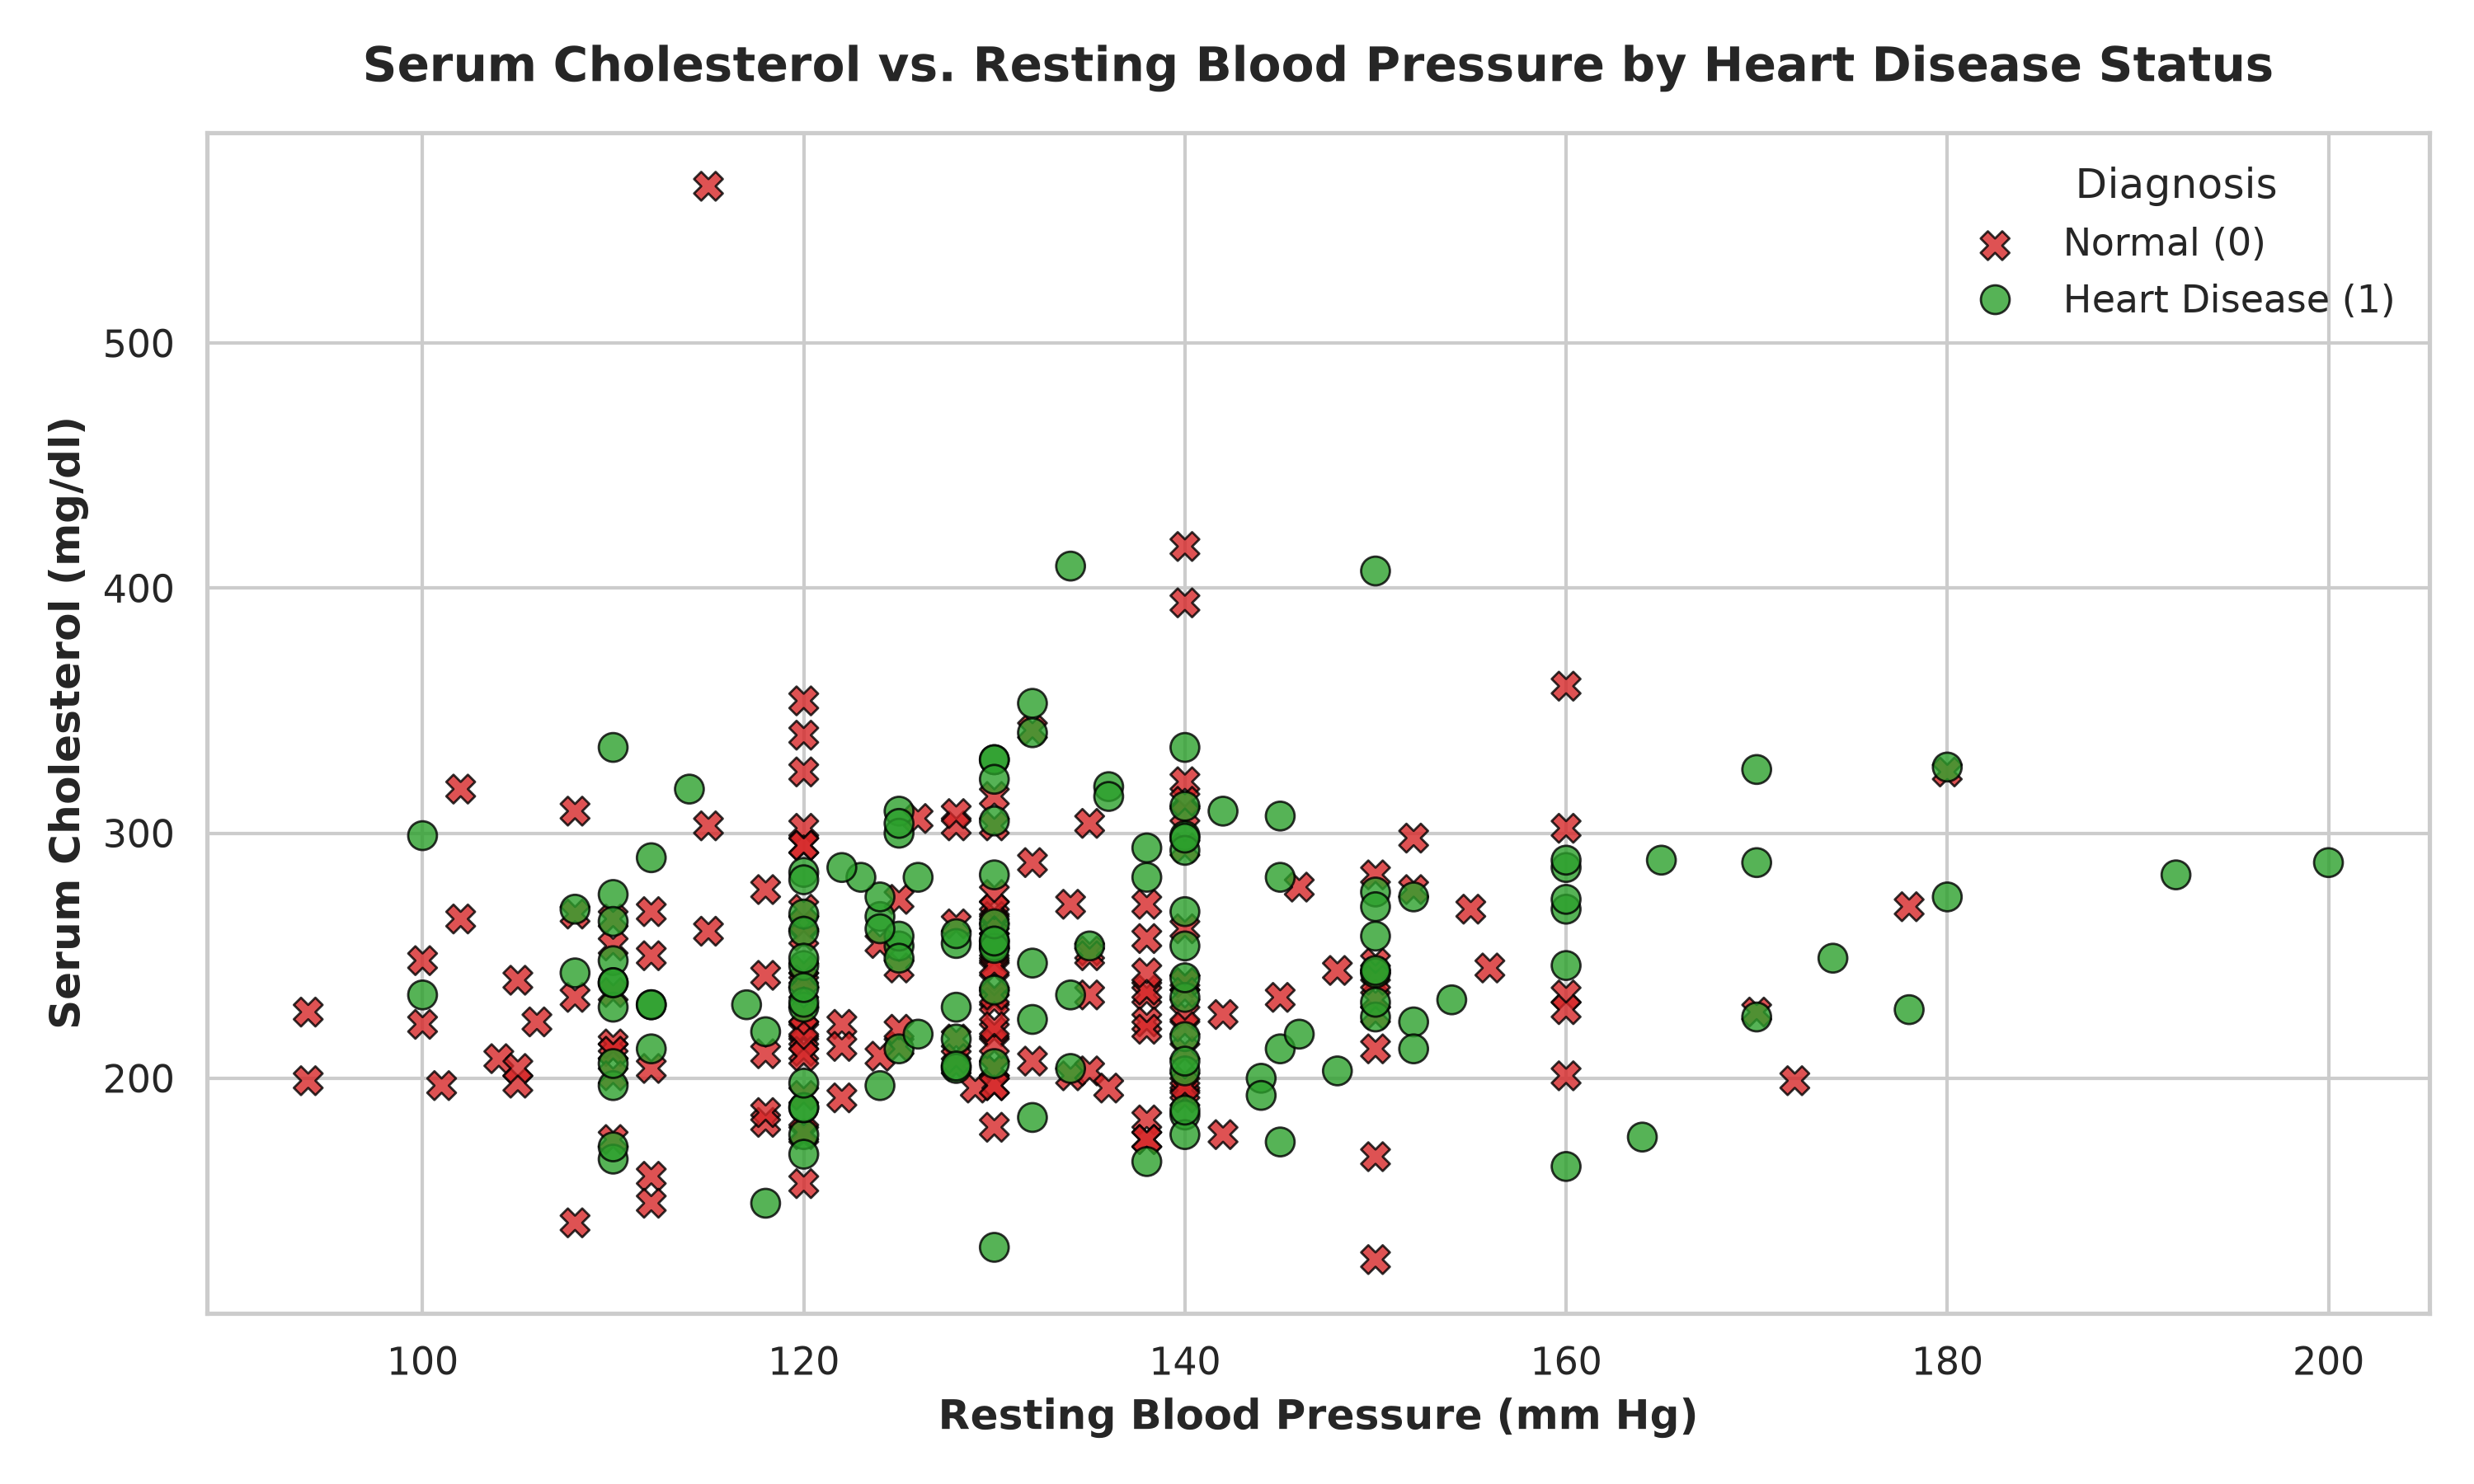

In [9]:
# Serum Cholesterol vs Blood Pressure Scatter
plot_cholesterol_bp_scatter(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "03_cholesterol_bp_scatter.png"))


G:\New folder\Thiranex\Theranex-project\thiranex_task4_real_world_health_project\src\analysis.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normal (0)', 'Heart Disease (1)'])


[SAVED] Max heart rate boxplot saved to: ..\visualizations\04_max_heart_rate_boxplot.png


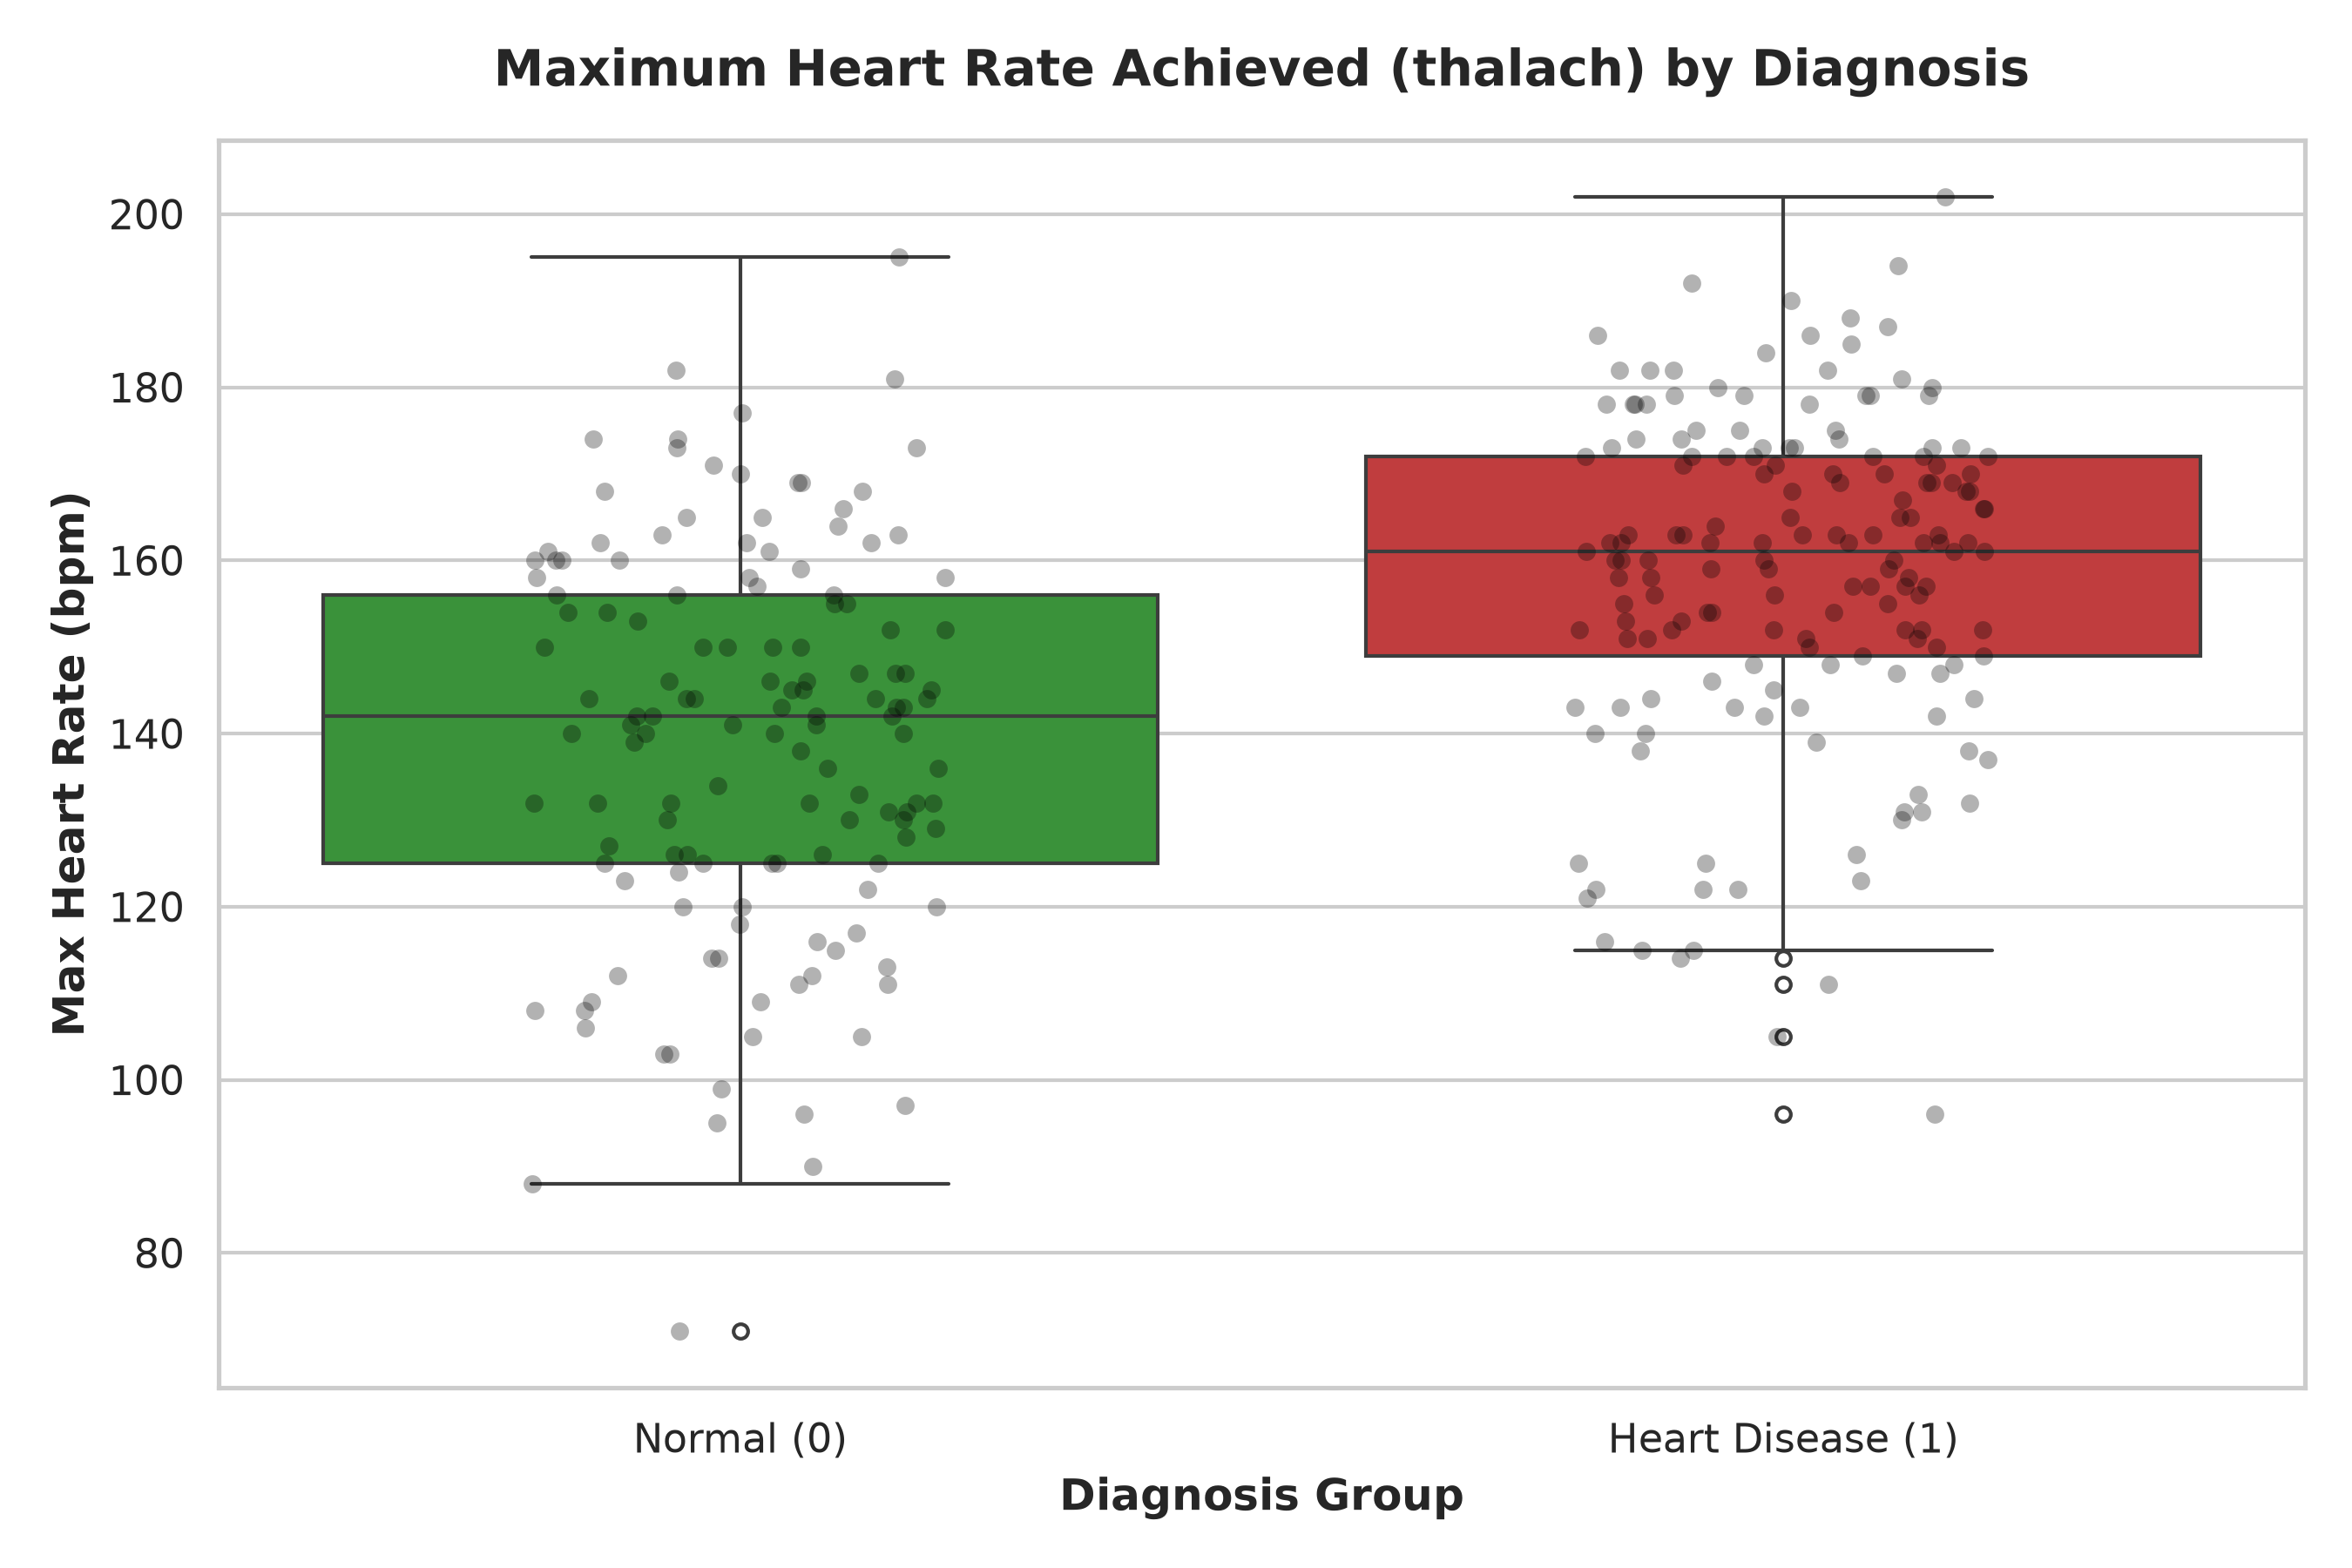

In [10]:
# Max Heart Rate (thalach) Boxplot
plot_max_heart_rate_boxplot(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "04_max_heart_rate_boxplot.png"))


[SAVED] Correlation heatmap saved to: ..\visualizations\05_correlation_heatmap.png


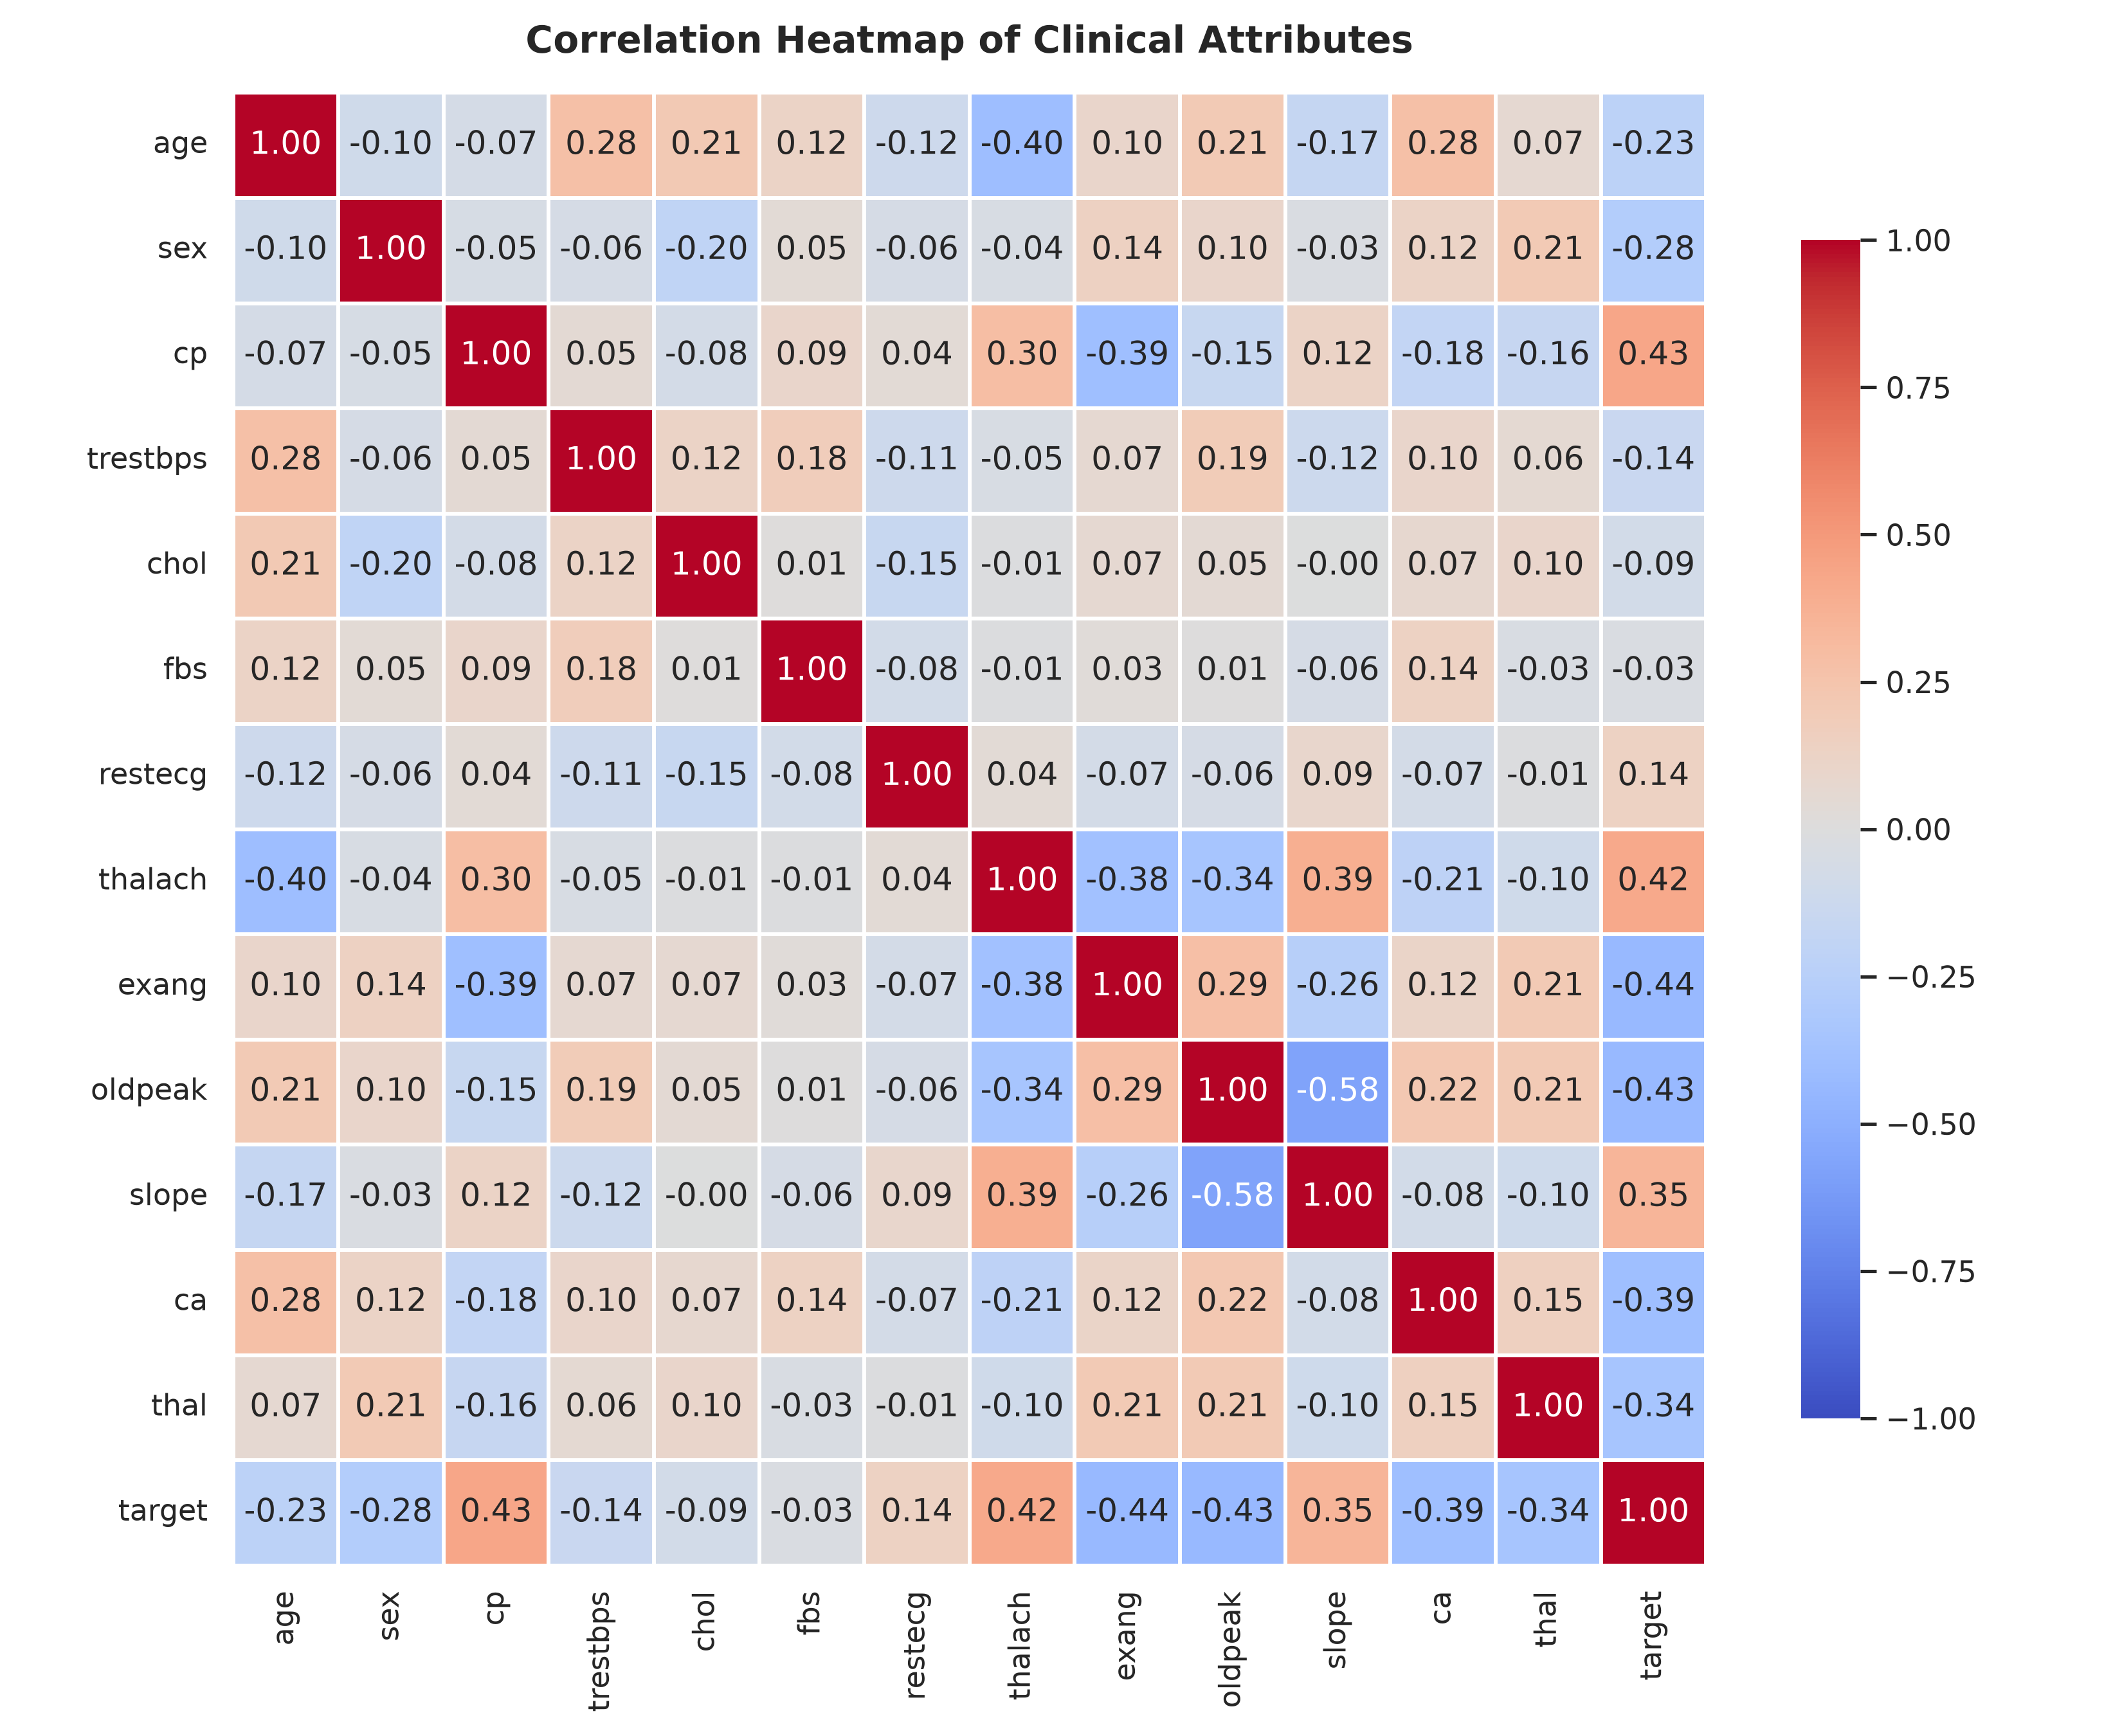

In [11]:
# Clinical Correlation Heatmap
plot_correlation_heatmap(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "05_correlation_heatmap.png"))


G:\New folder\Thiranex\Theranex-project\thiranex_task4_real_world_health_project\src\analysis.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Normal (0)', 'Heart Disease (1)'])
G:\New folder\Thiranex\Theranex-project\thiranex_task4_real_world_health_project\src\analysis.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No Exercise Angina (0)', 'Exercise Angina (1)'])


[SAVED] Exercise angina & ST depression plot saved to: ..\visualizations\06_exercise_angina_st_depression.png


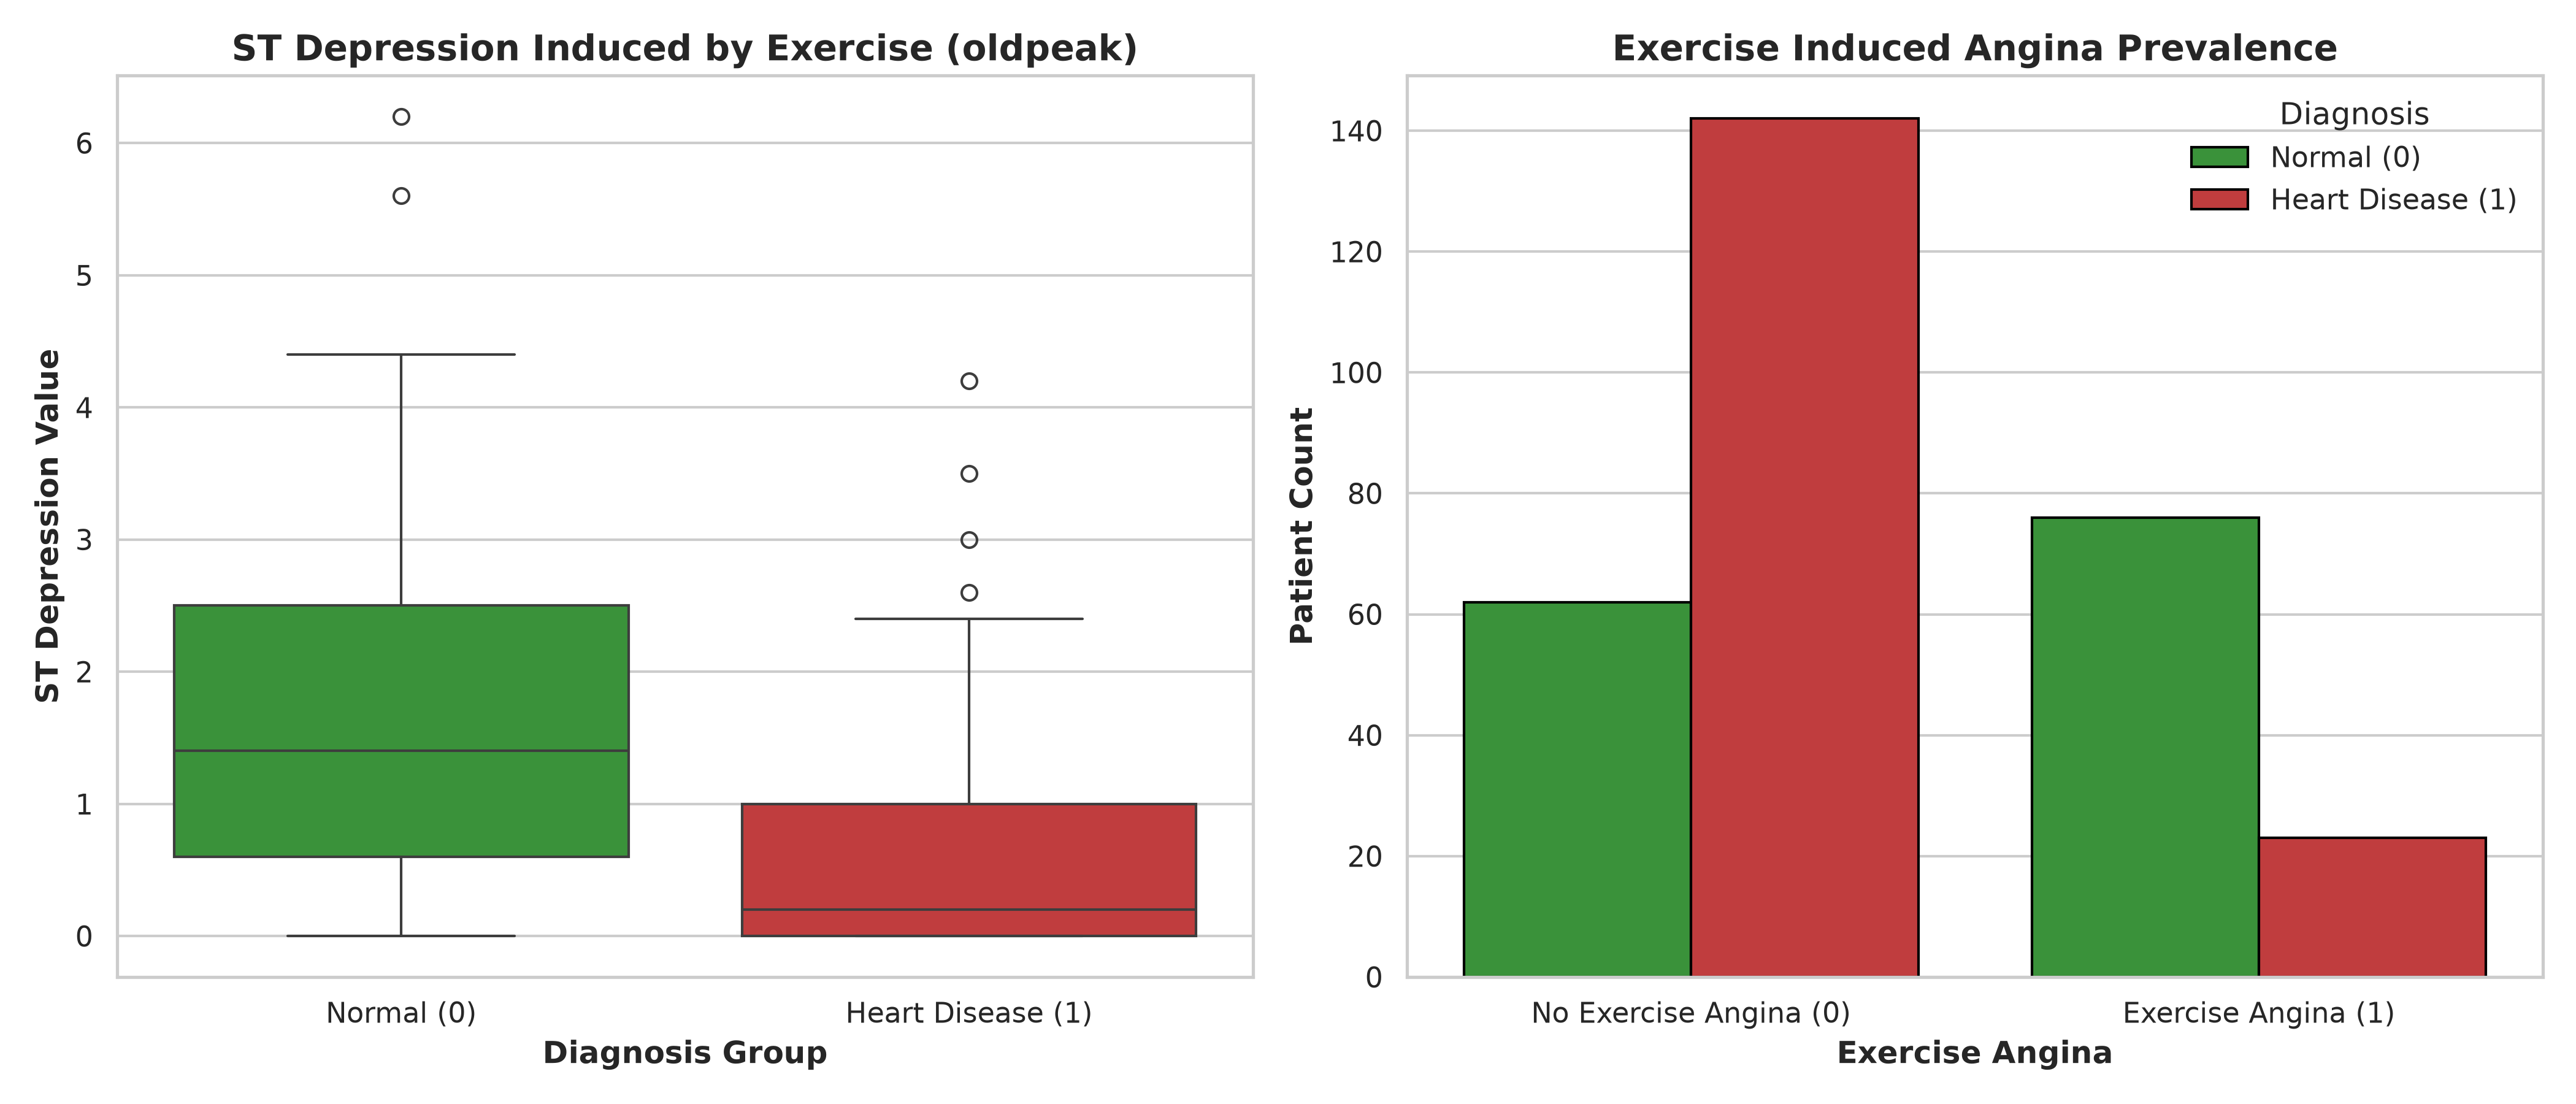

In [12]:
# Exercise Angina & ST Depression (oldpeak)
plot_exercise_angina_st_depression(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "06_exercise_angina_st_depression.png"))


[SAVED] Pairwise feature correlation plot saved to: ..\visualizations\07_pairwise_feature_importance.png


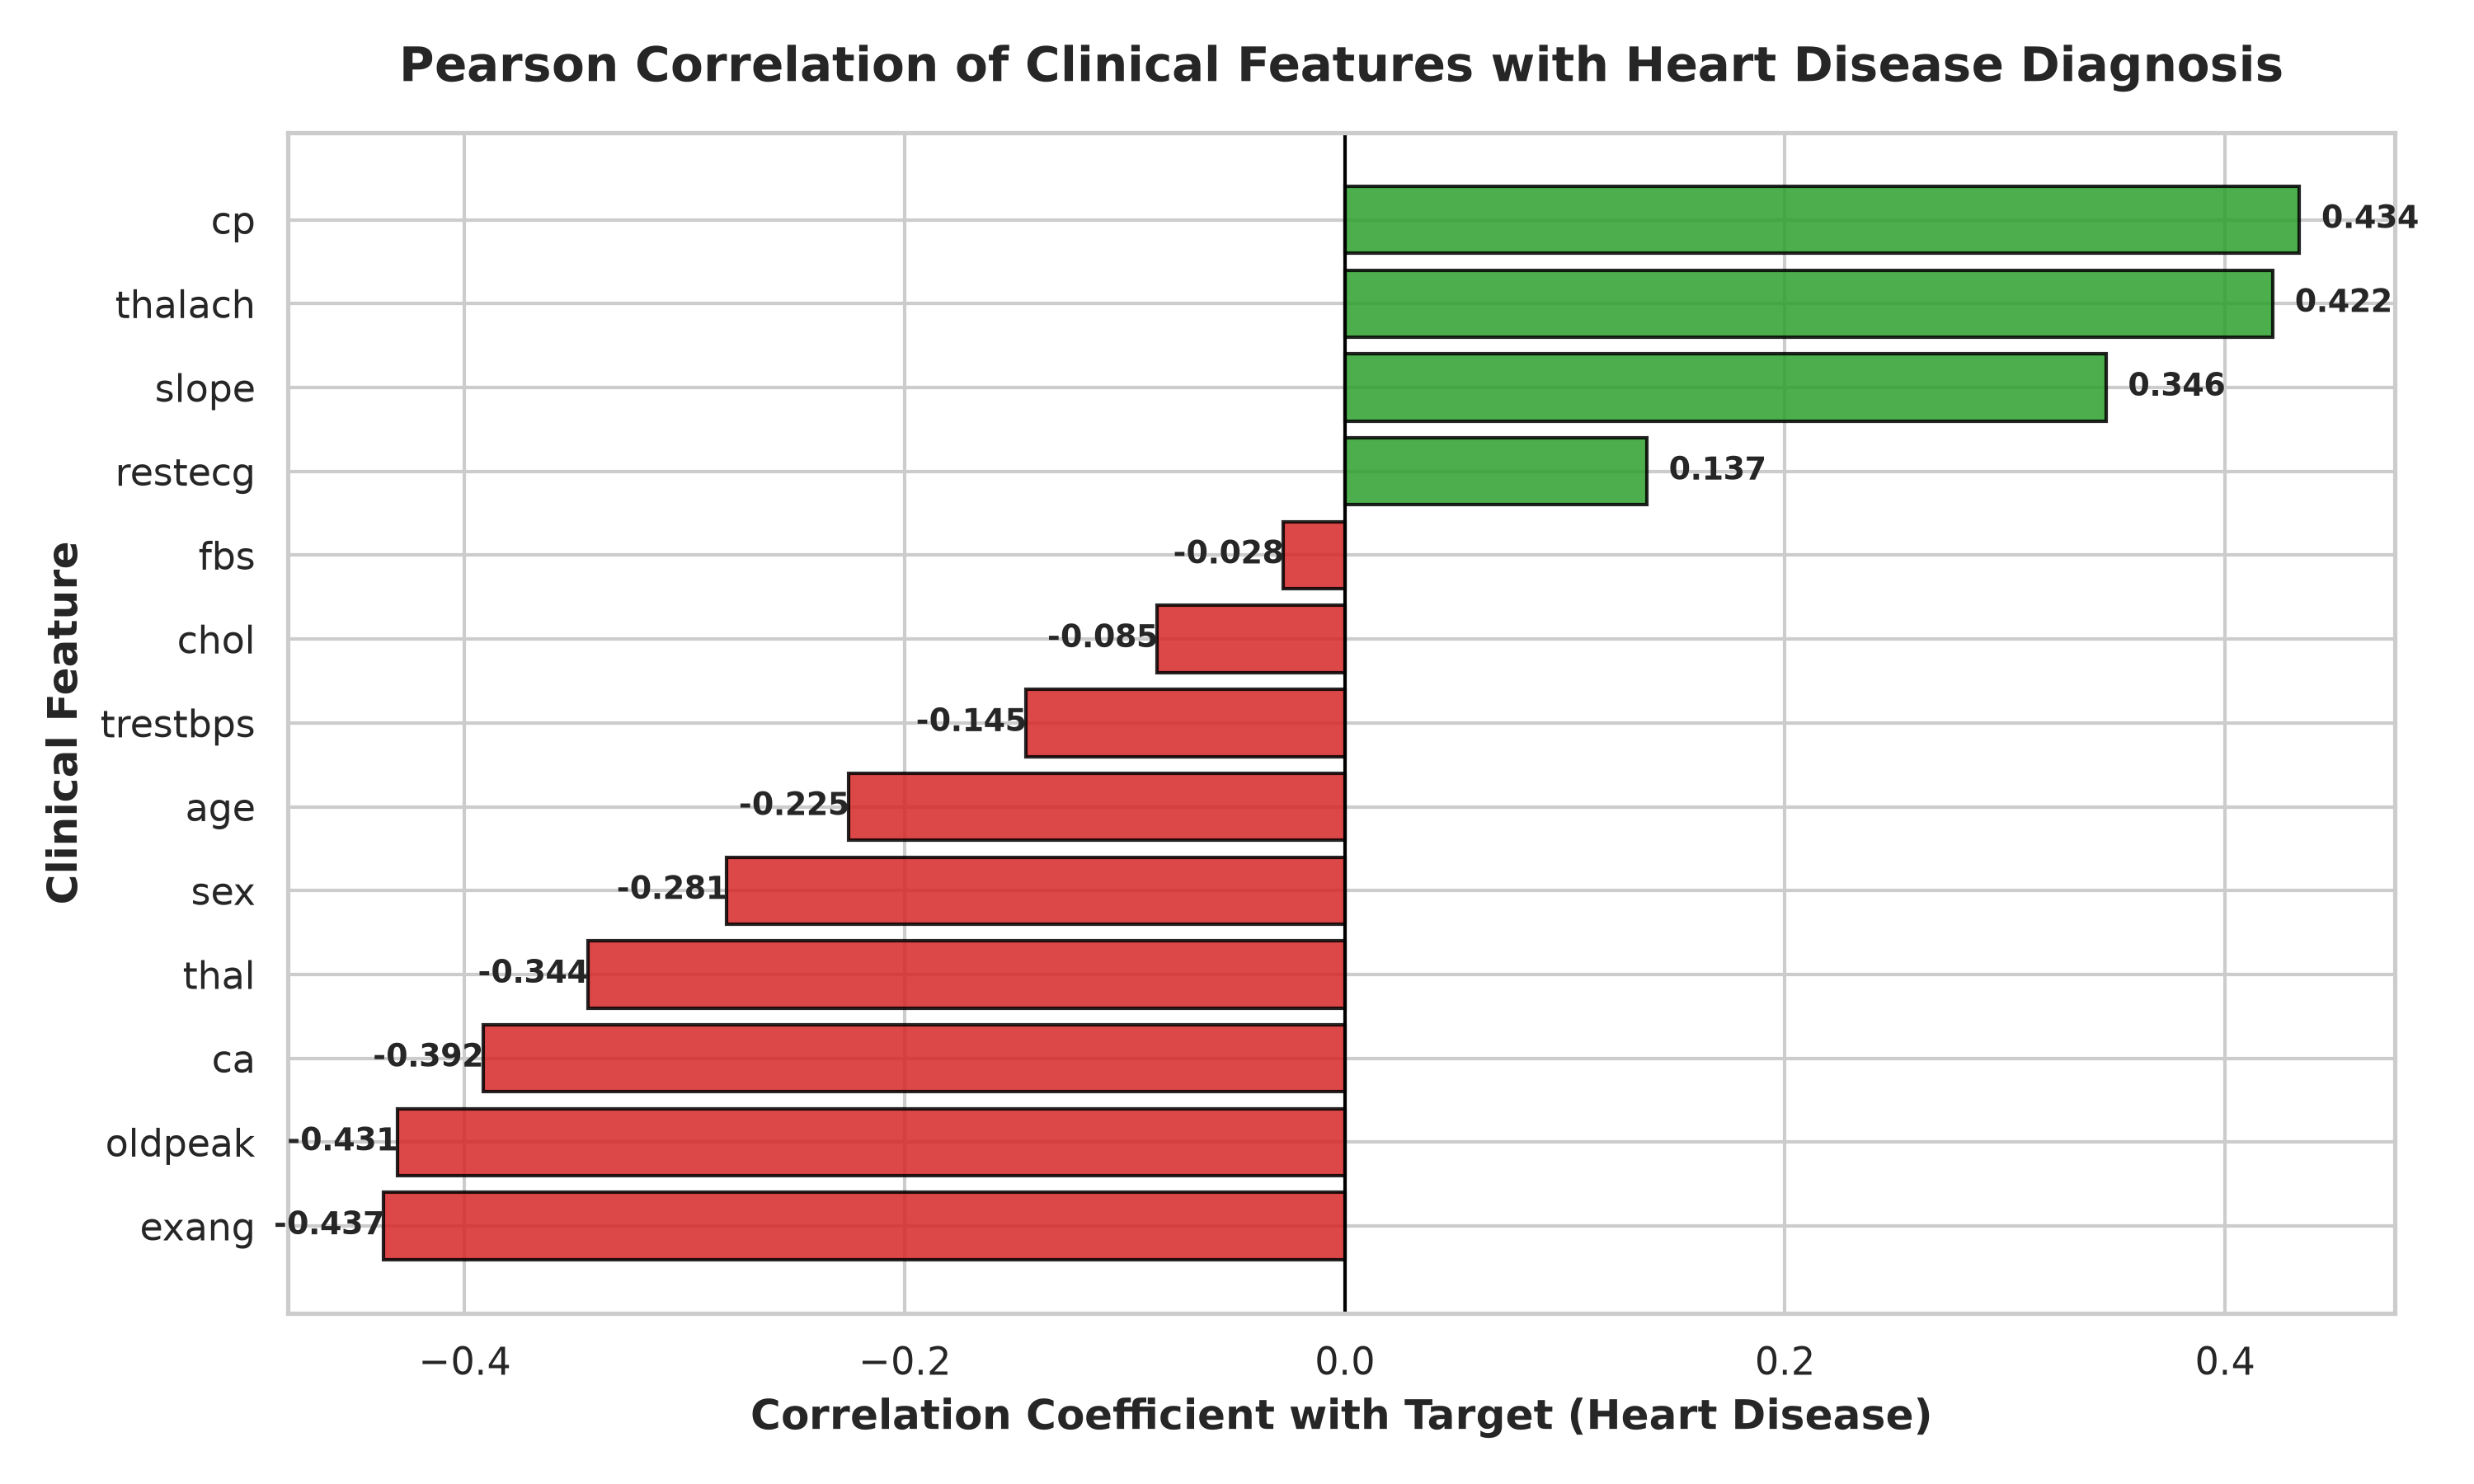

In [13]:
# Pairwise Feature Correlation Ranking
plot_pairwise_feature_importance(df_raw, viz_dir)
Image(filename=os.path.join(viz_dir, "07_pairwise_feature_importance.png"))


---
### 9. Stratified Train / Test Split
We split the 302 clean patient records into 80% Training (`X_train`: 242 rows) and 20% Holdout Testing (`X_test`: 60 rows) while preserving disease prevalence ratios (`random_state=42`).


In [14]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

print(f"Train Partition: {X_train.shape[0]} patients")
print(f"Test Partition : {X_test.shape[0]} patients")


[INFO] Stratified Split -> Train: 243 rows, Test: 59 rows (Test ratio: 0.2)
Train Partition: 243 patients
Test Partition : 59 patients


---
### 10. Supervised Machine Learning Model Training
We fit three classification pipelines:
1. **Baseline Model**: L2-Regularized Logistic Regression
2. **Decision Tree Classifier**: Depth-constrained decision tree (`max_depth=5`)
3. **Random Forest Classifier**: Ensemble of 100 decision trees (`max_depth=6`)


In [15]:
pipelines = build_model_pipelines(preprocessor)
trained_models = train_all_models(pipelines, X_train, y_train)


[INFO] Training model: Baseline (Logistic Regression)...
[SUCCESS] Trained: Baseline (Logistic Regression)
[INFO] Training model: Decision Tree...
[SUCCESS] Trained: Decision Tree
[INFO] Training model: Random Forest...


[SUCCESS] Trained: Random Forest


---
### 11. Model Evaluation on Holdout Test Set
We evaluate holdout test predictions across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.


In [16]:
df_results, detailed_metrics = evaluate_all_models(trained_models, X_test, y_test)

print("=== HOLDOUT TEST SET PERFORMANCE METRICS ===")
display(df_results)


=== HOLDOUT TEST SET PERFORMANCE METRICS ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline (Logistic Regression),0.8136,0.8387,0.8125,0.8254,0.8588
1,Random Forest,0.7966,0.8333,0.7812,0.8065,0.8553
2,Decision Tree,0.7627,0.7647,0.8125,0.7879,0.7882


---
### 12. Visual Evaluation Dashboards

#### 12.1 Confusion Matrices


[SAVED] Confusion matrices plot saved to: ..\visualizations\08_confusion_matrices.png


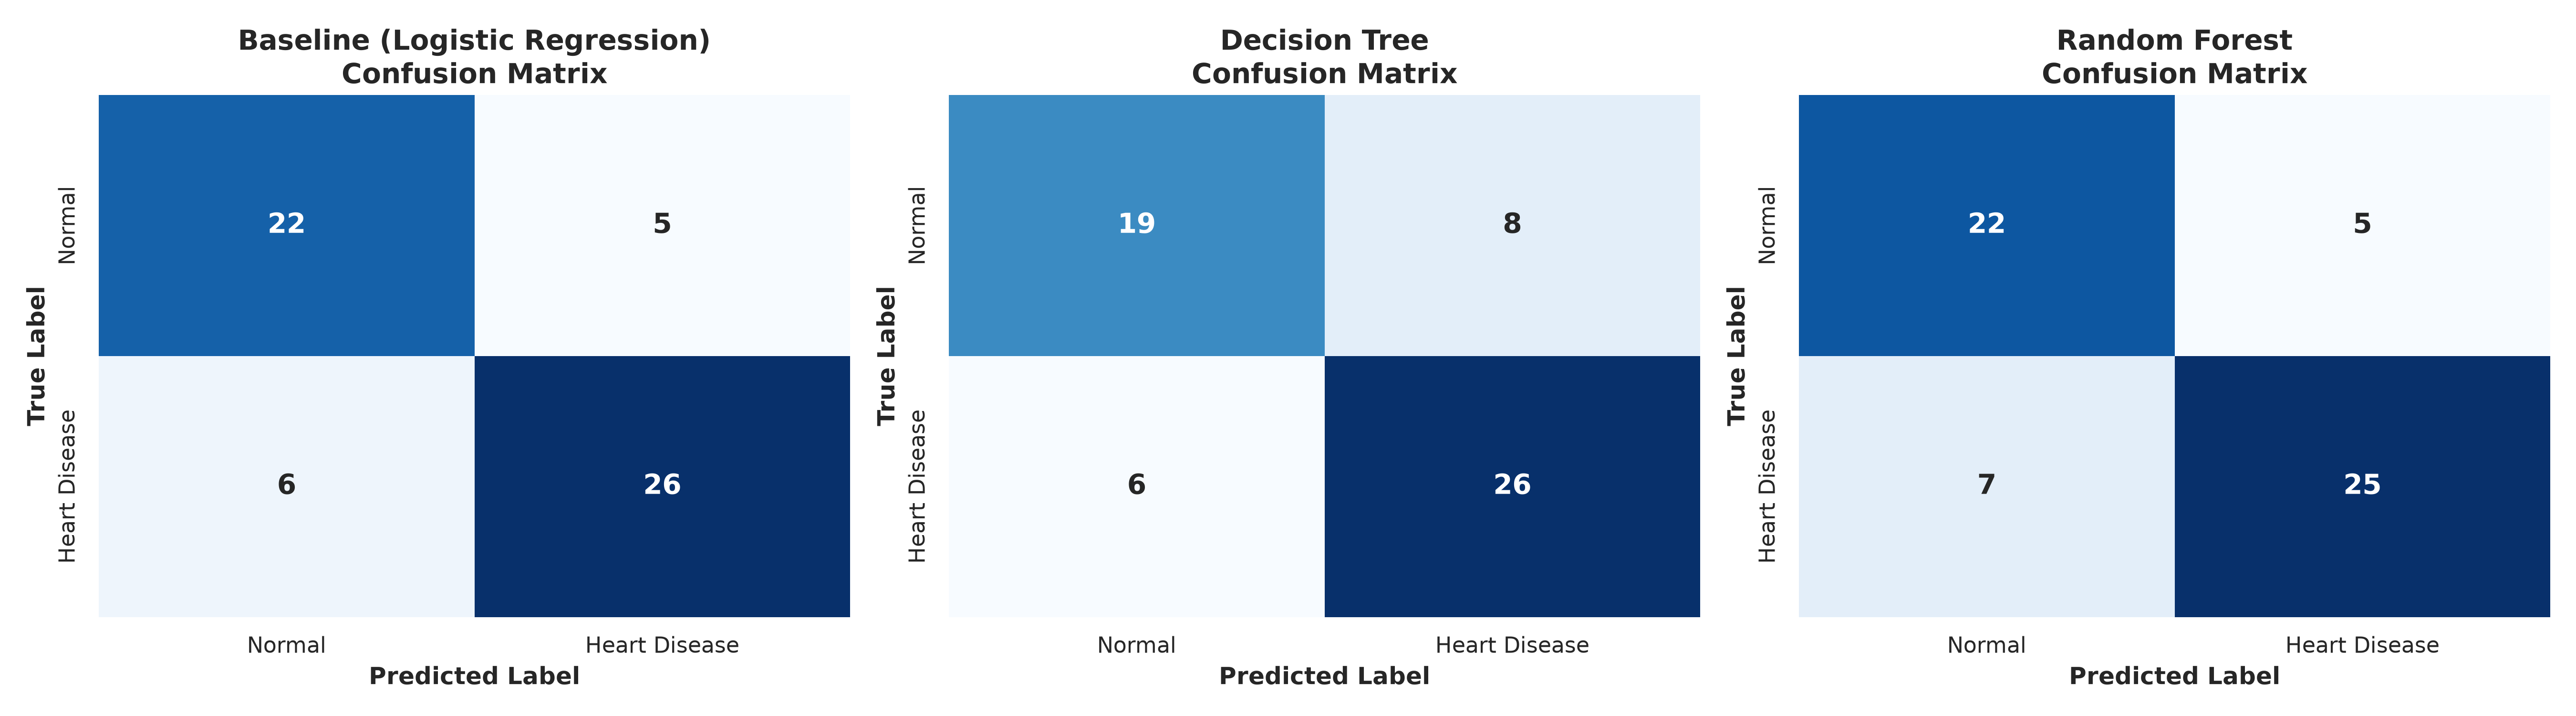

In [17]:
plot_confusion_matrices(detailed_metrics, y_test, viz_dir)
Image(filename=os.path.join(viz_dir, "08_confusion_matrices.png"))


#### 12.2 ROC Curves & AUC Score Comparison

[SAVED] ROC curves plot saved to: ..\visualizations\09_roc_curves.png


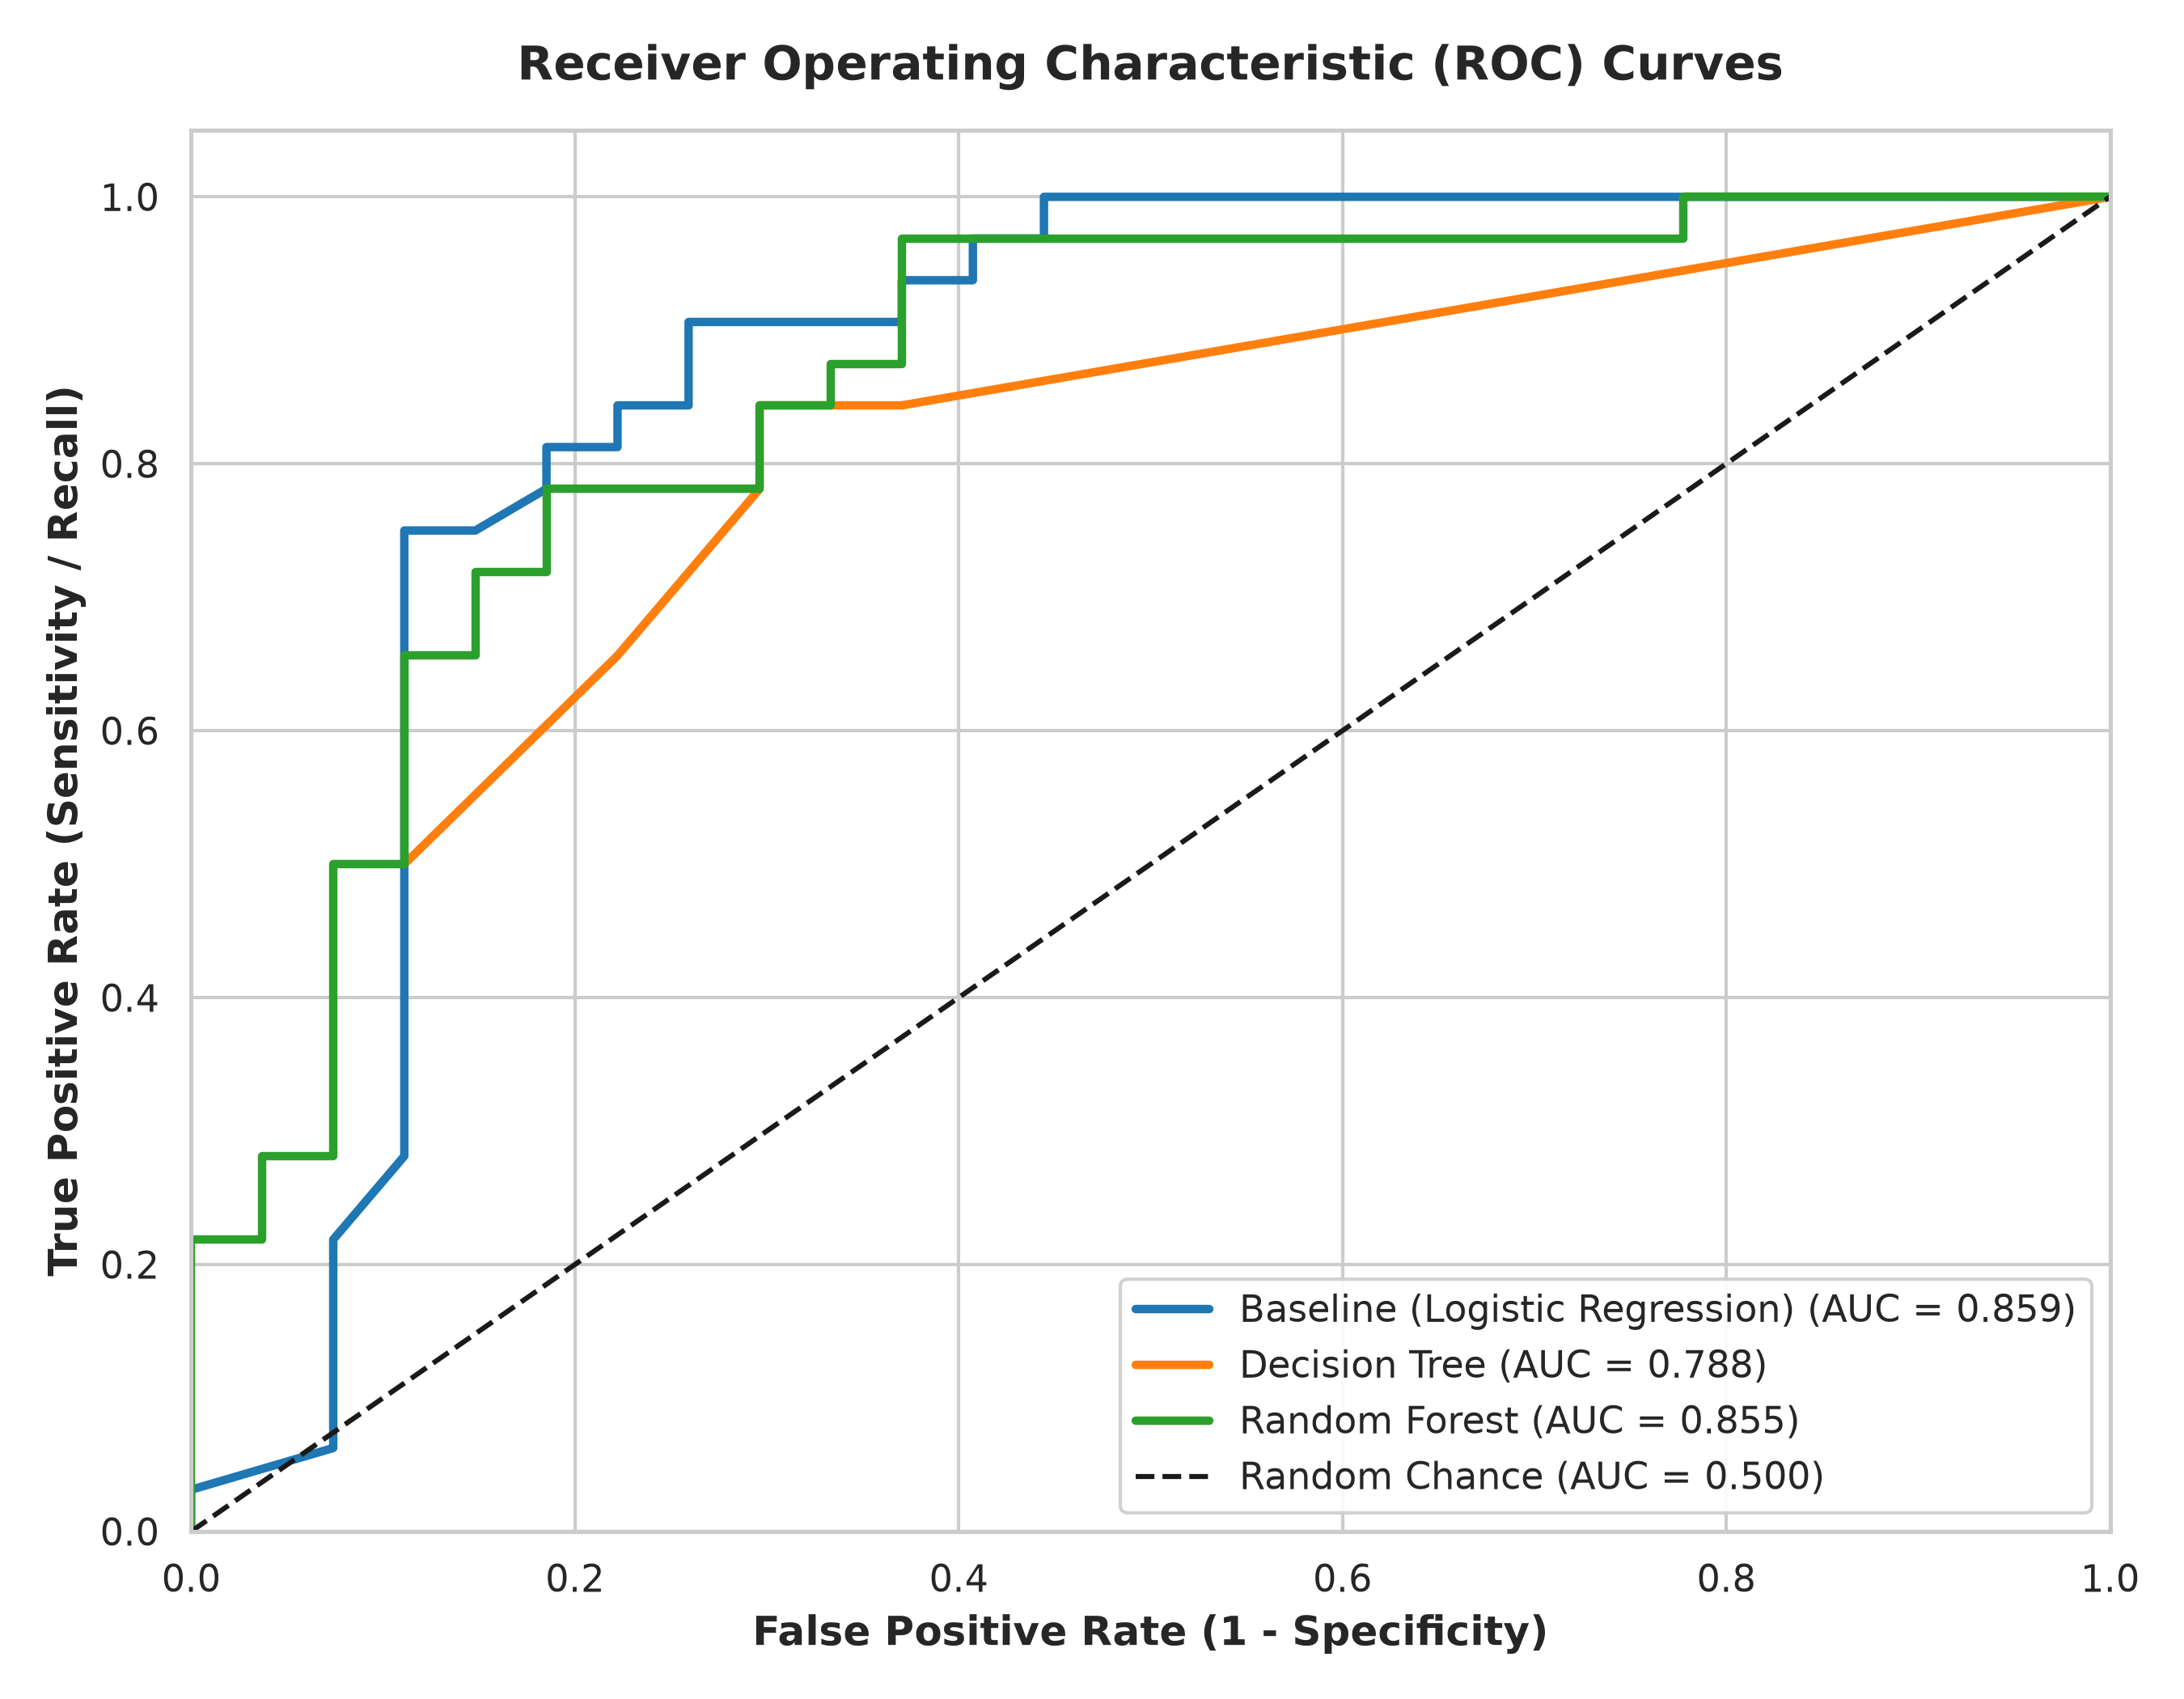

In [18]:
plot_roc_curves(detailed_metrics, y_test, viz_dir)
Image(filename=os.path.join(viz_dir, "09_roc_curves.png"))


#### 12.3 Overall Model Performance Comparison Bar Chart

[SAVED] Model comparison plot saved to: ..\visualizations\10_model_comparison.png


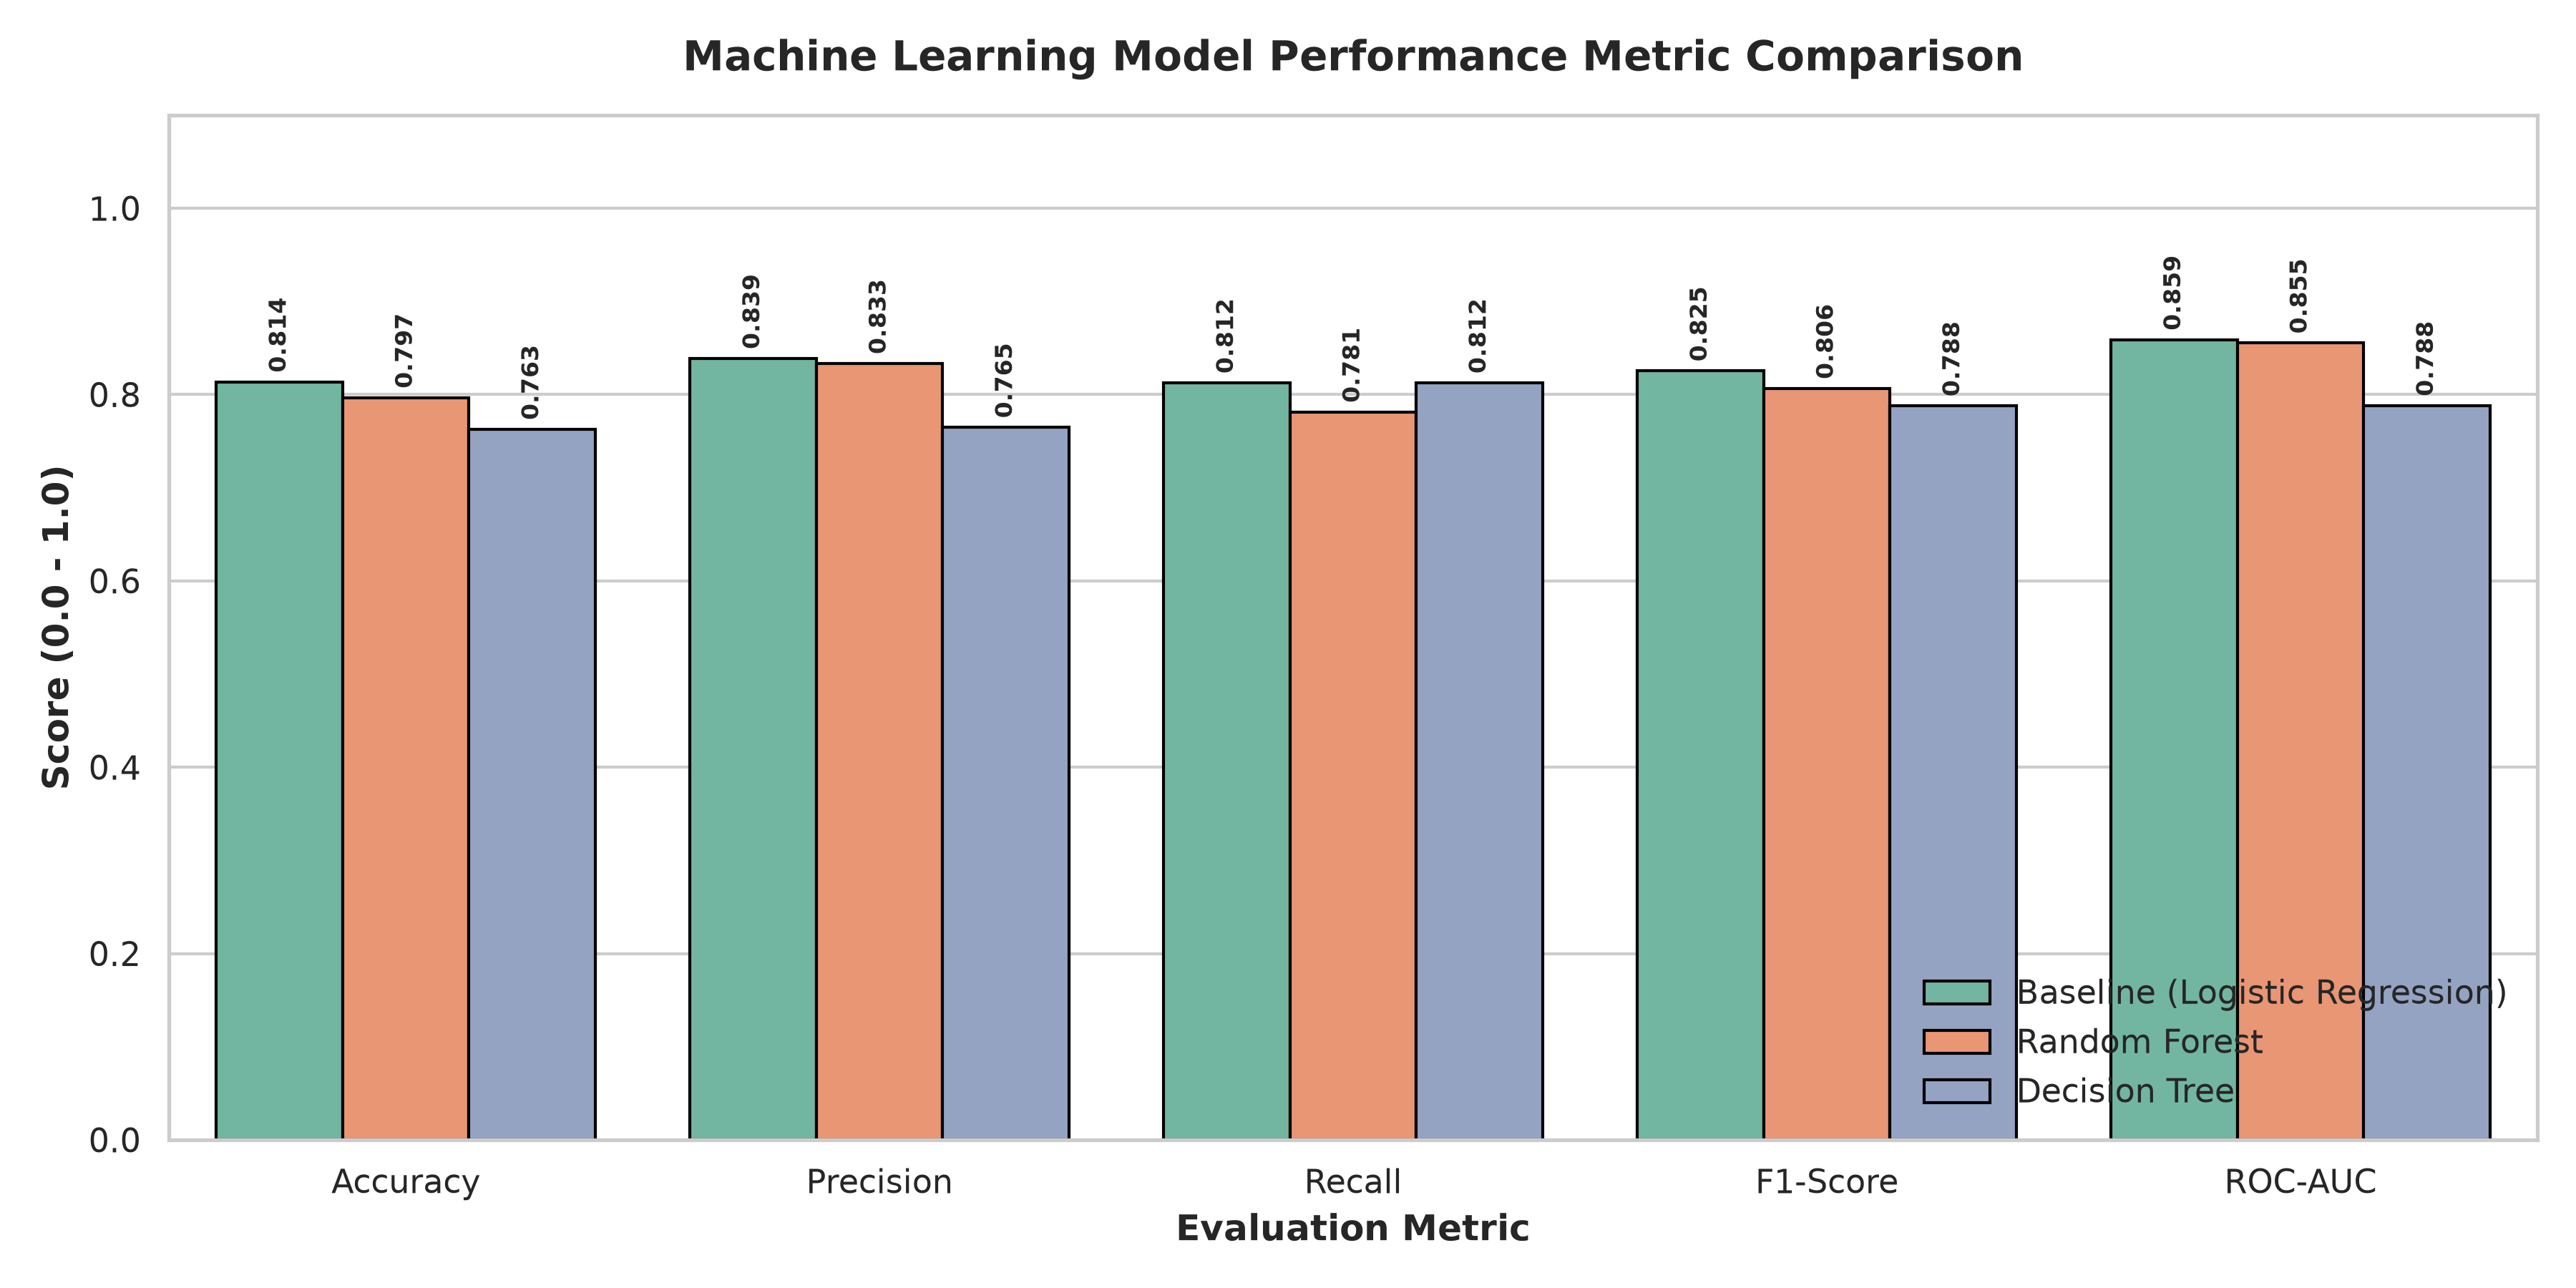

In [19]:
plot_model_comparison(df_results, viz_dir)
Image(filename=os.path.join(viz_dir, "10_model_comparison.png"))


---
### 13. Clinical Feature Importance Analysis
We extract relative feature importances from the Random Forest classifier to identify top clinical predictors.

> **Note on Medical Interpretation:** Feature importance scores reflect mathematical utility for model decision splits. High feature importance indicates strong predictive association, **not direct clinical causation**.


[SAVED] Feature importance plot saved to: ..\visualizations\11_feature_importance.png


,Feature,Importance
0,thal_2,0.1276
1,oldpeak,0.0996
2,exang_1,0.0918
3,thalach,0.0902
4,age,0.0776
5,thal_3,0.0764
6,slope_2,0.0612
7,cp_2,0.0547
8,chol,0.0525
9,trestbps,0.0483


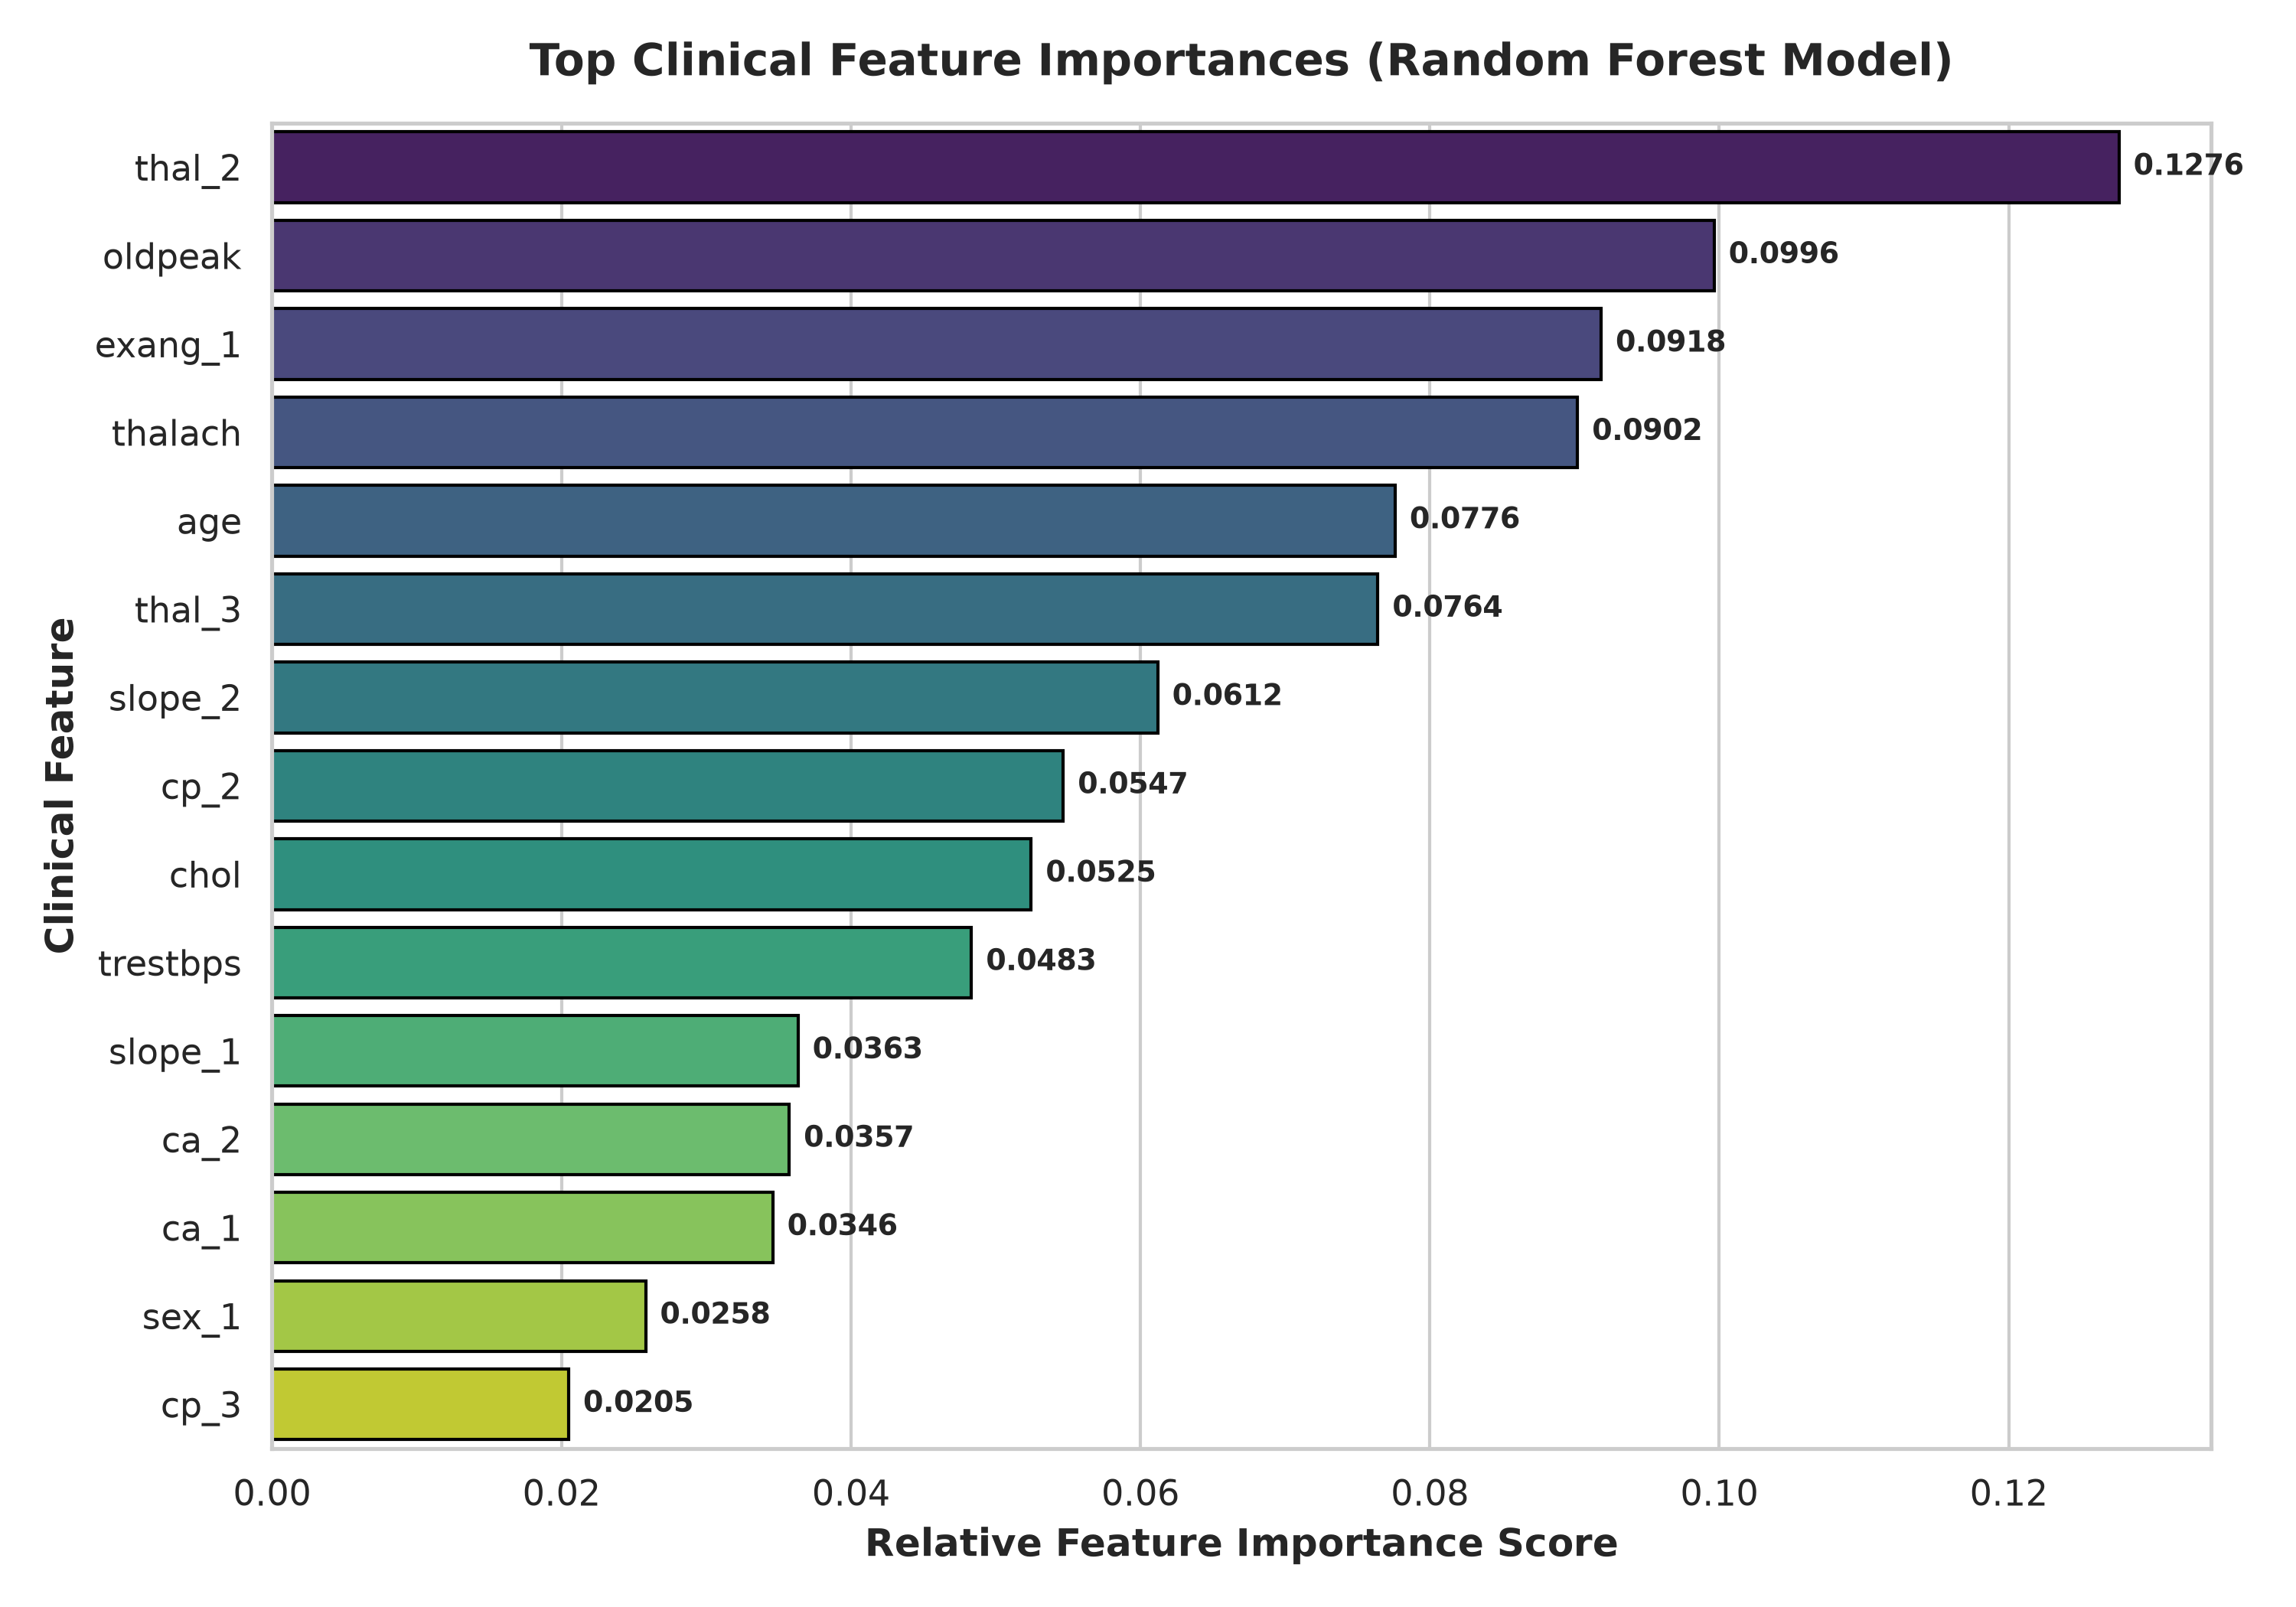

In [20]:
rf_model = trained_models["Random Forest"]
df_imp = plot_feature_importance(rf_model, X_train, viz_dir, top_n=15)

display(df_imp)
Image(filename=os.path.join(viz_dir, "11_feature_importance.png"))


---
### 14. Key Findings & Clinical Risk Insights

1. **Model Performance**:
   - **Baseline Logistic Regression** achieved the highest overall **ROC-AUC score of 0.8588**, **Accuracy of 81.36%**, and **Precision of 83.87%**.
   - **Random Forest** achieved **0.8553 ROC-AUC** and **79.66% Accuracy**.

2. **Top Clinical Risk Predictors**:
   - `thal_2` (Fixed Defect Thalassemia): Strongest single predictor of heart disease.
   - `oldpeak` (ST depression induced by exercise): Higher ST depression correlates strongly with ischemia/disease.
   - `exang_1` (Exercise Induced Angina): Angina during exercise increases risk score.
   - `thalach` (Maximum Heart Rate): Lower max heart rate during stress testing is associated with higher disease risk.
   - `age`: Higher age increases baseline cardiovascular risk.

---
### 15. Study Limitations
* **Dataset Scale**: The UCI dataset comprises 303 patient records from a single medical center (Cleveland Clinic). Larger multi-center datasets are needed for broader clinical generalization.
* **Demographic Representation**: Higher male representation (68%) in the dataset.

---
### 16. Conclusion & Model Serialization
The final selected Logistic Regression model pipeline is saved to `models/best_health_model.joblib` for demonstration.
